## Set up

In [1]:
#importing packages
#packages for directory and file handling
import os
import glob

#packages for flow cytometry data handling
import FlowCal

#packages for data handling
import pandas as pd
import numpy as np

#packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#fontsize =7
def custom_theme_7pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 7
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 7
    plt.rcParams['legend.title_fontsize'] = 7
    plt.rcParams['axes.labelsize'] = 7
    plt.rcParams['axes.titlesize'] = 7
    plt.rcParams['axes.grid'] = False

    #additionas to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42 


#fontsize = 6
def custom_theme_6pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 6
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 6
    plt.rcParams['legend.title_fontsize'] = 6
    plt.rcParams['axes.labelsize'] = 6
    plt.rcParams['axes.titlesize'] = 6
    plt.rcParams['axes.grid'] = False

    #additions to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42


#fontsize =5
def custom_theme_5pt():
    sns.set_style("whitegrid")
    plt.rcParams['axes.edgecolor'] = 'black'
    plt.rcParams['axes.linewidth'] = 0.3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.3
    plt.rcParams['xtick.minor.size'] = 2
    plt.rcParams['xtick.minor.width'] = 0.2
    plt.rcParams['ytick.minor.size'] = 2
    plt.rcParams['ytick.minor.width'] = 0.2
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['font.size'] = 5
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['legend.fontsize'] = 5
    plt.rcParams['legend.title_fontsize'] = 5
    plt.rcParams['axes.labelsize'] = 5
    plt.rcParams['axes.titlesize'] = 5
    plt.rcParams['axes.grid'] = False

    #additions to theme
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

## Import 

In [3]:
#get all subdirs in fcs_files (corresponding to experiments)
os.getcwd()
files = glob.glob('fcs_files/AS_210520_d11_cVM_cells/*fcs')
sorted_files = sorted(files)
sorted_files[:5]

#import all files in the dictionary and save as new dictionary
imported_files = {}
for filename in sorted_files:
    fcs_data = FlowCal.io.FCSData(filename)
    imported_files[filename] = fcs_data

#check the shape of the imported files
keys_shapes = []
for key, value in imported_files.items():
    keys_shapes.append(f"{key}: {value.shape}")

#make the output more readable (uncomment to inspect)

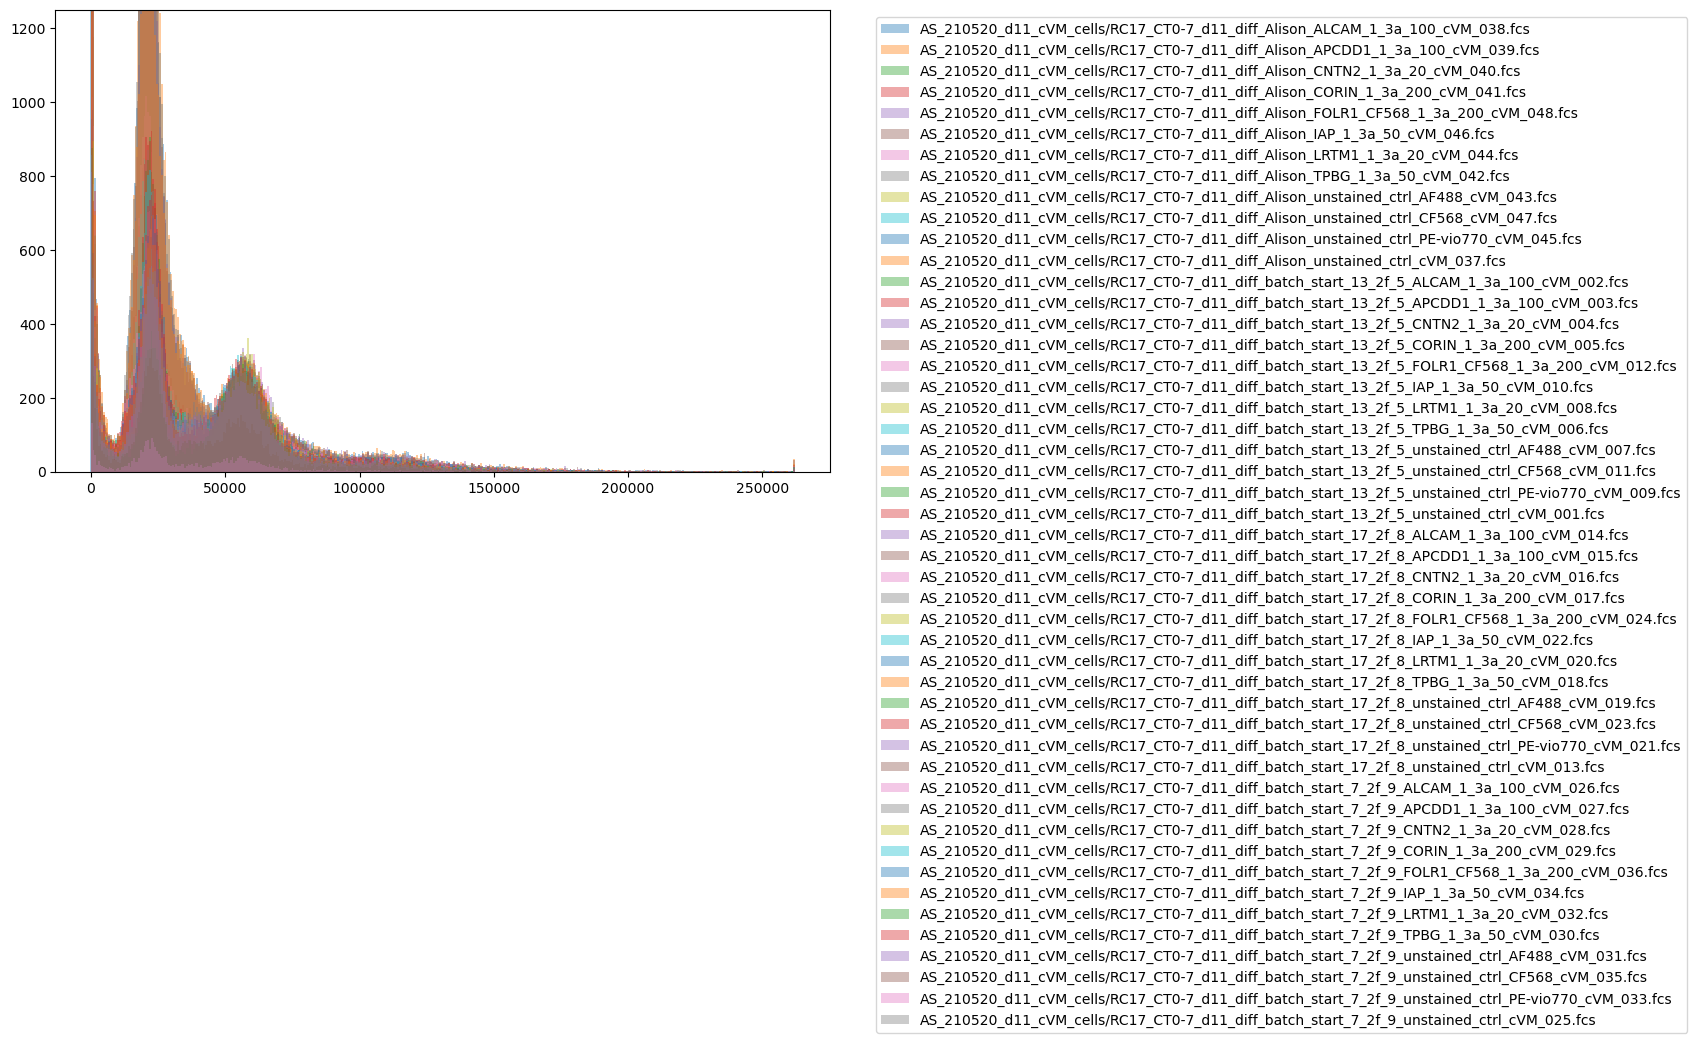

In [4]:
plt.figure(figsize=(10, 6)) # make the figure wider
for i, (filename, file) in enumerate(imported_files.items()):
    folder_name = os.path.basename(os.path.dirname(filename))  # Extract the folder name
    plt.hist(file[:, 'FSC-A'], bins=400, alpha=0.4, 
                label=f'{folder_name}/{os.path.basename(filename)}')

plt.ylim(0, 1250)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

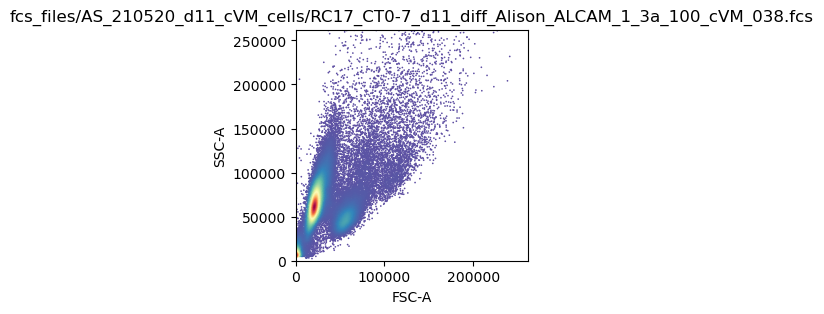

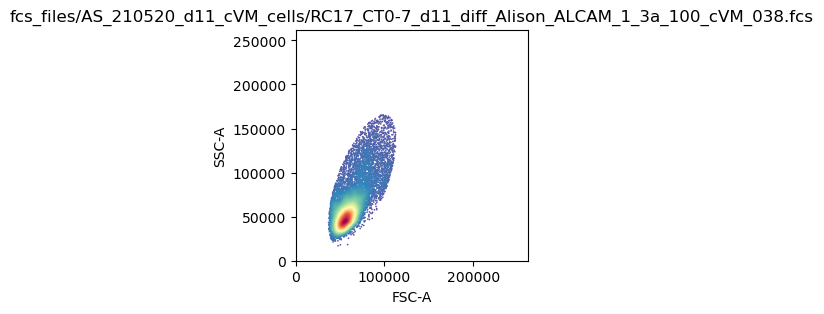

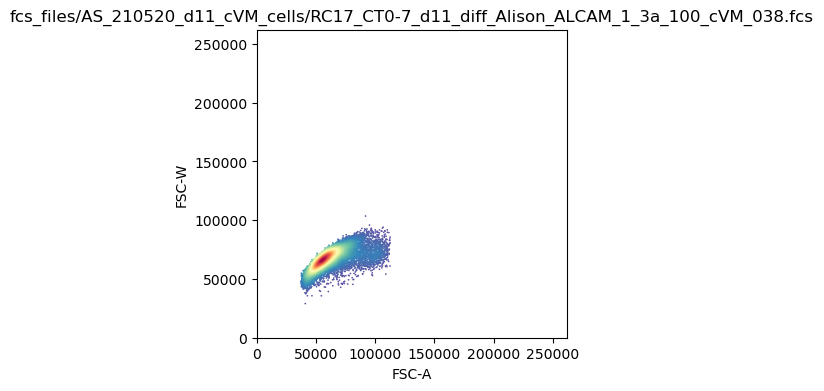

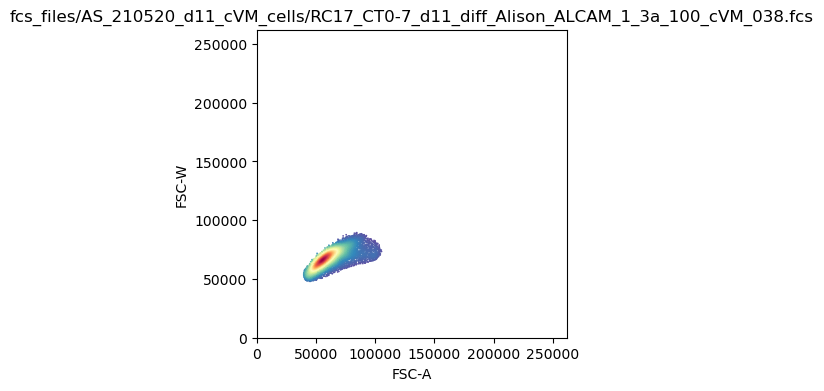

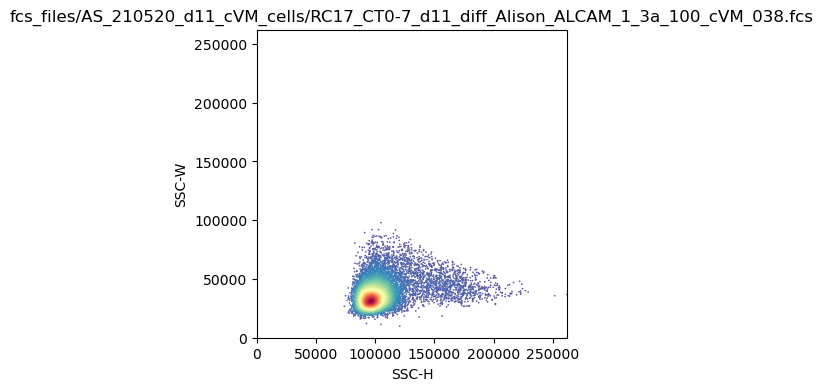

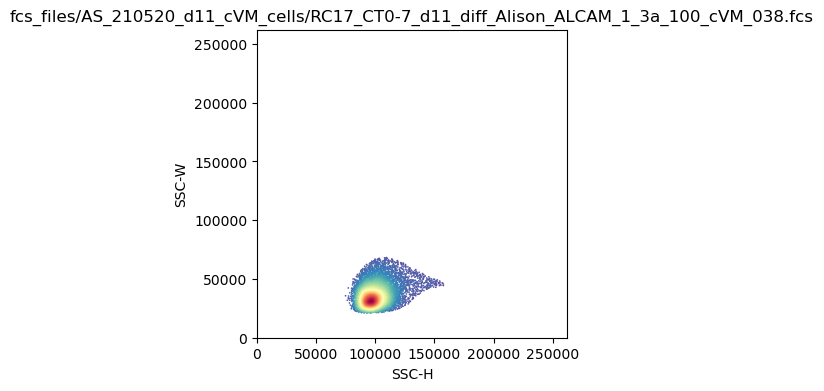

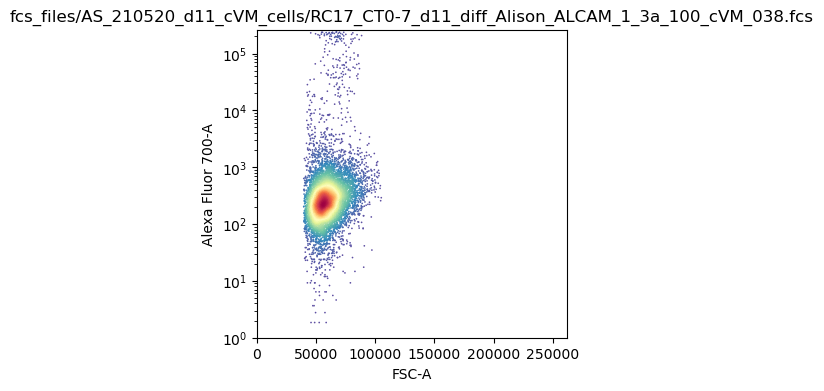

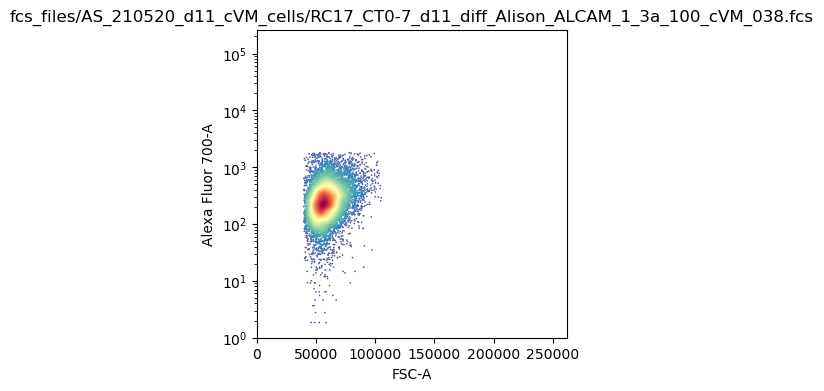

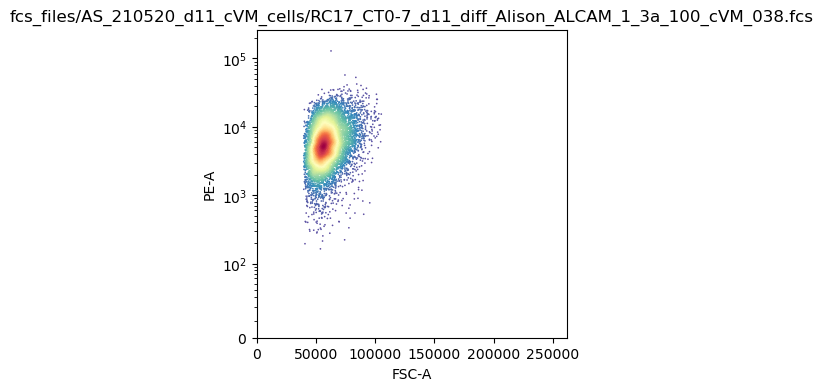

Number of events in gated sample: 8453


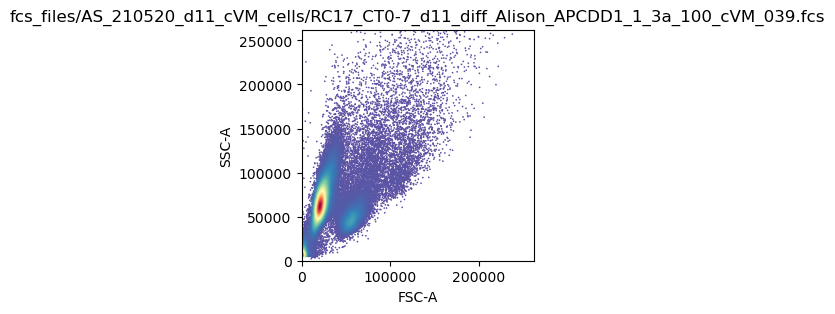

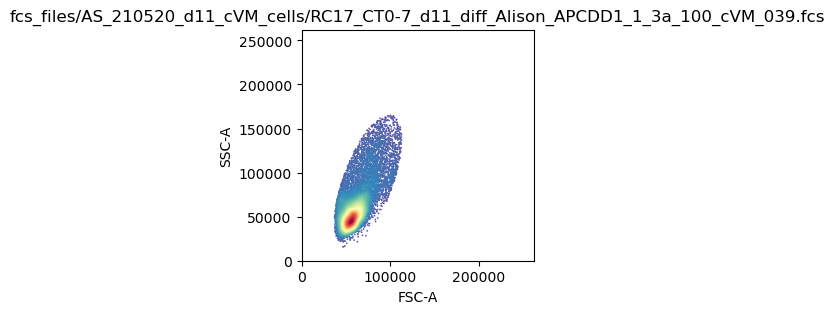

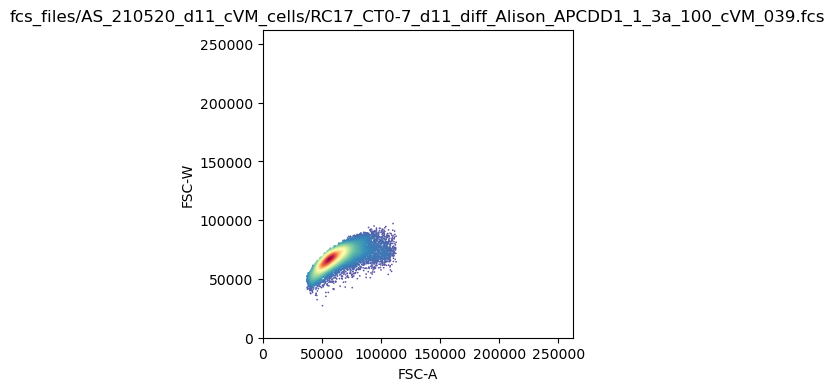

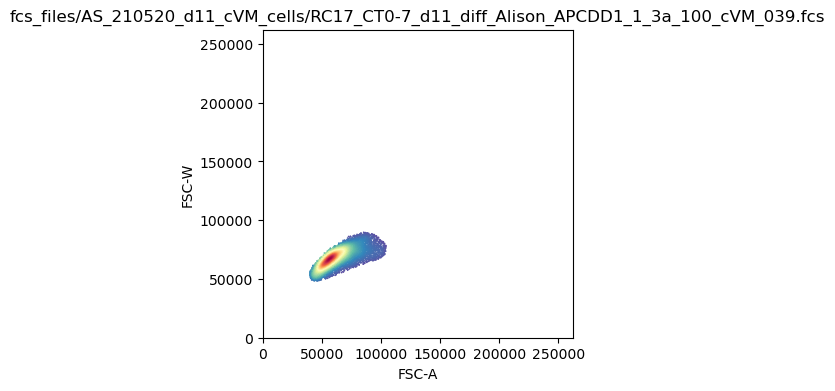

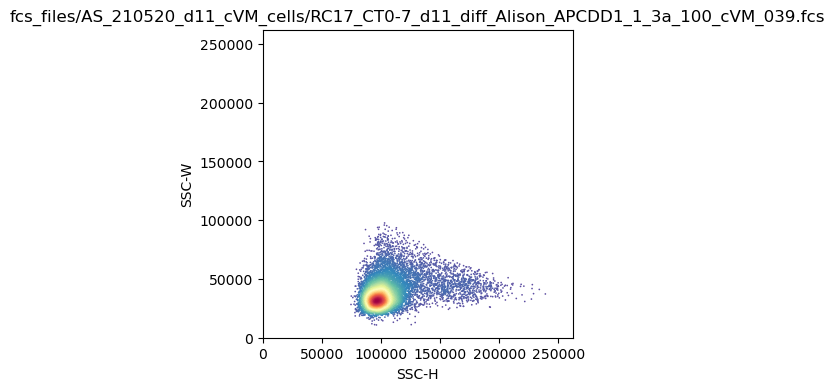

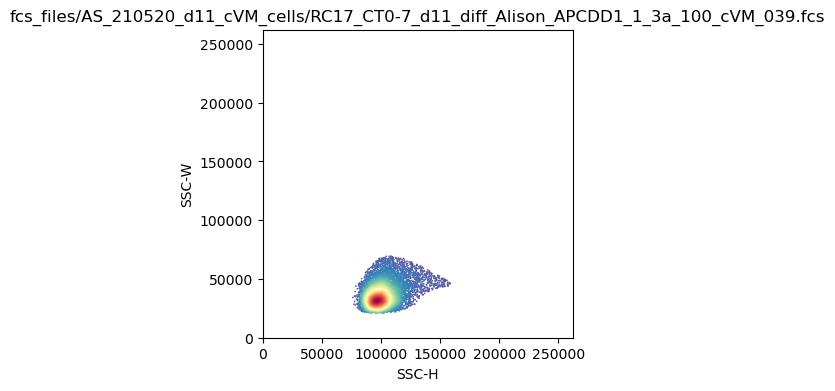

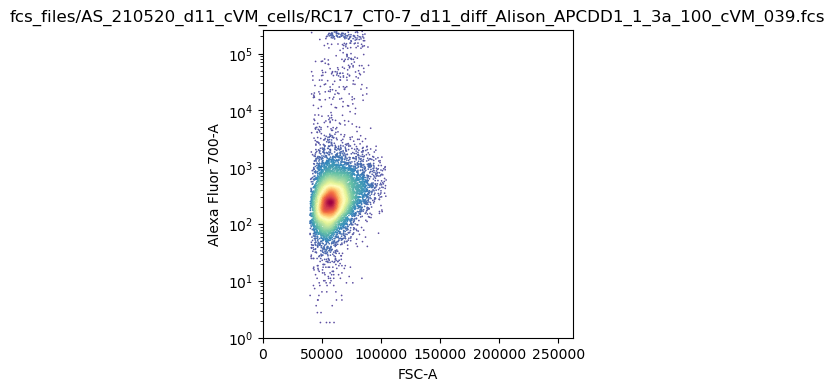

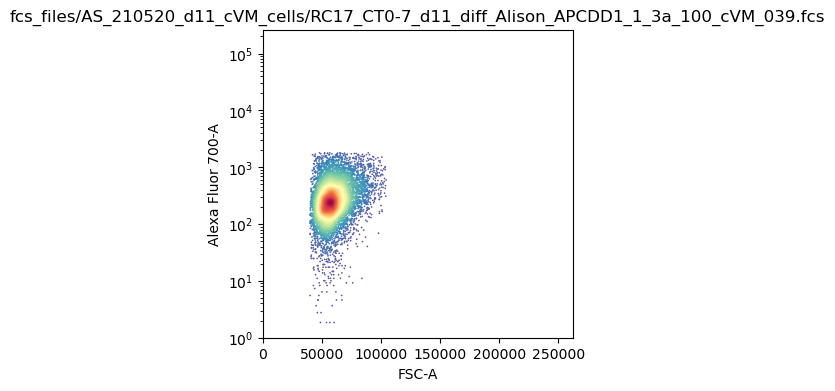

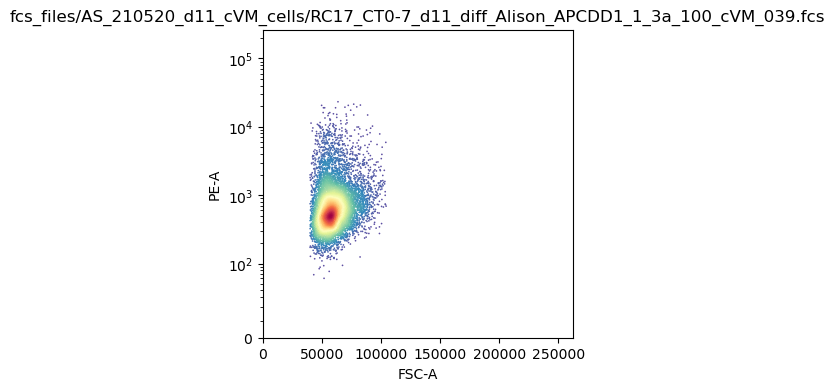

Number of events in gated sample: 8374


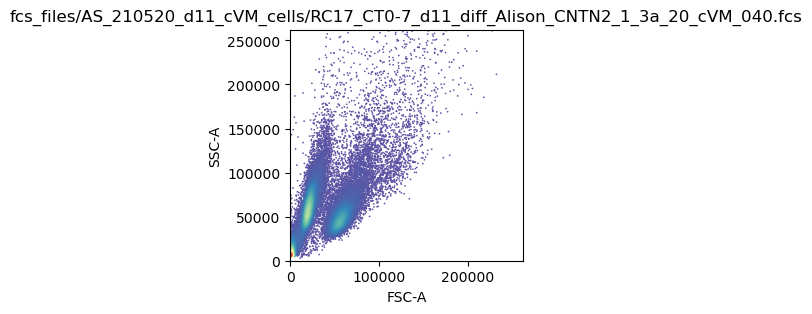

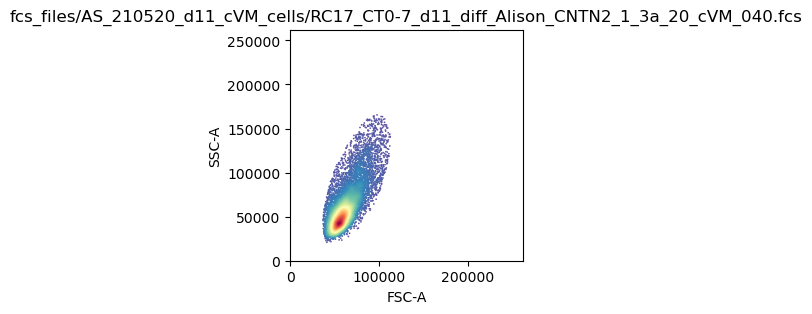

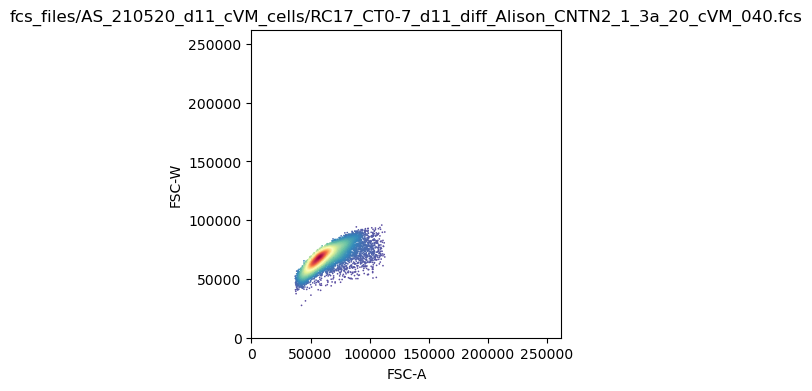

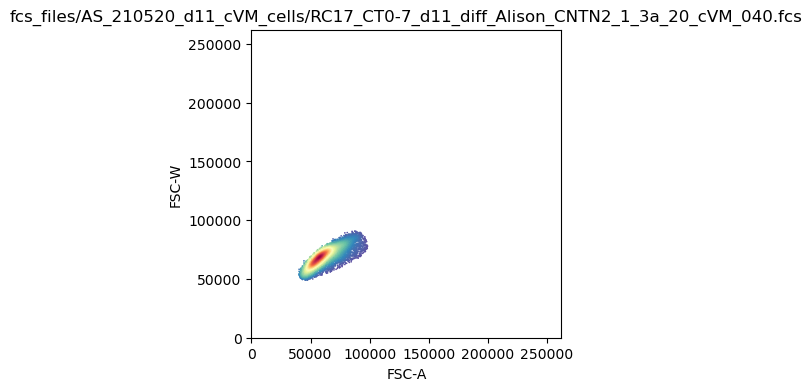

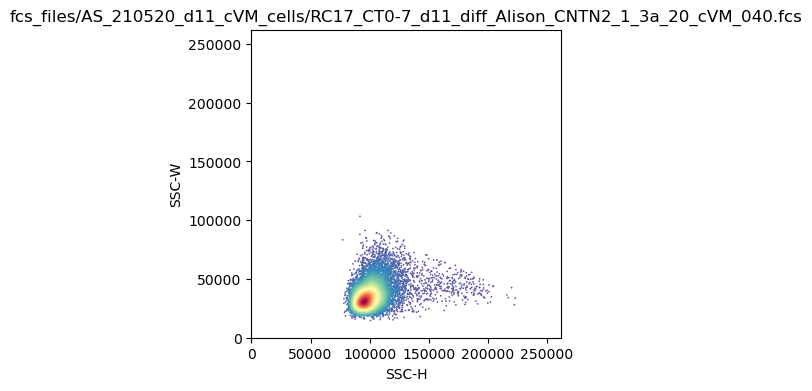

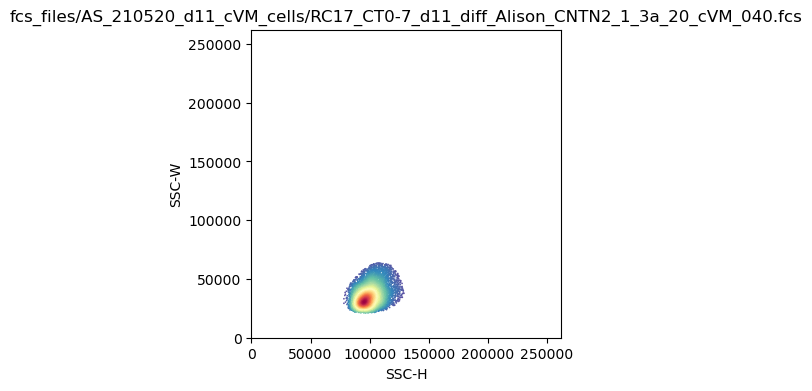

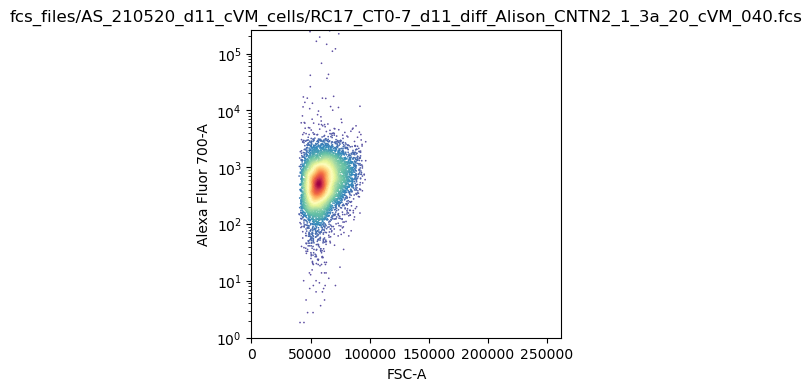

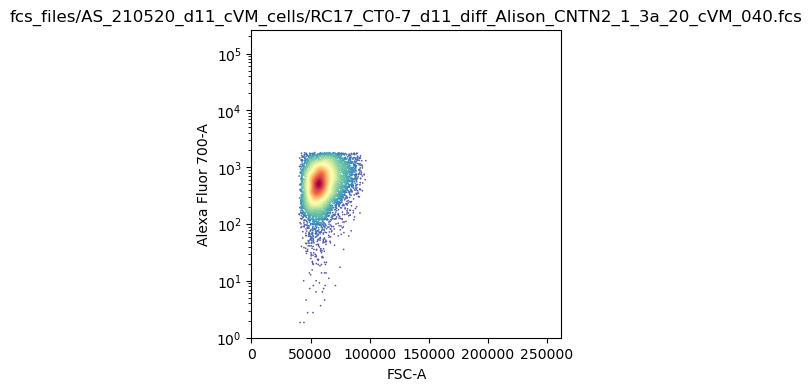

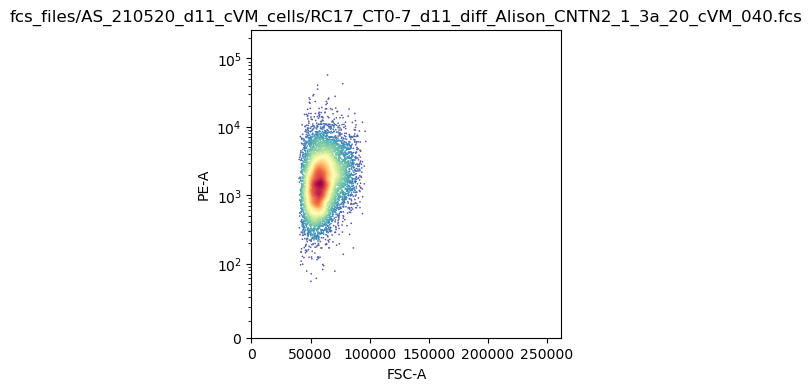

Number of events in gated sample: 7494


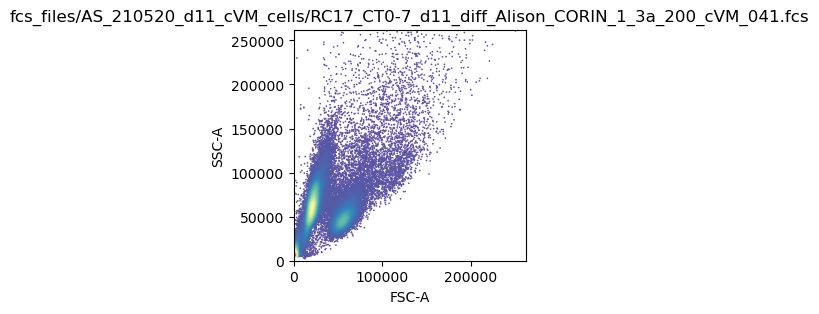

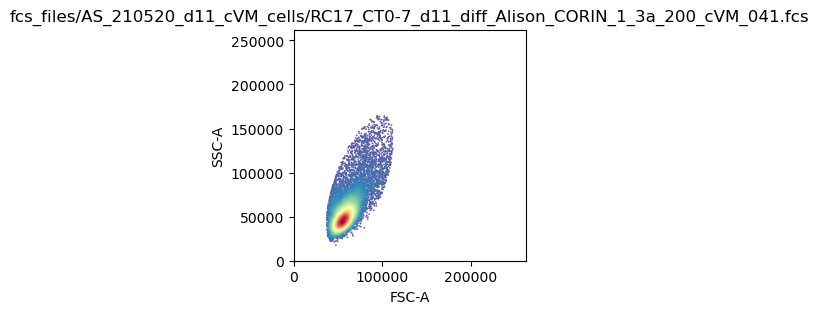

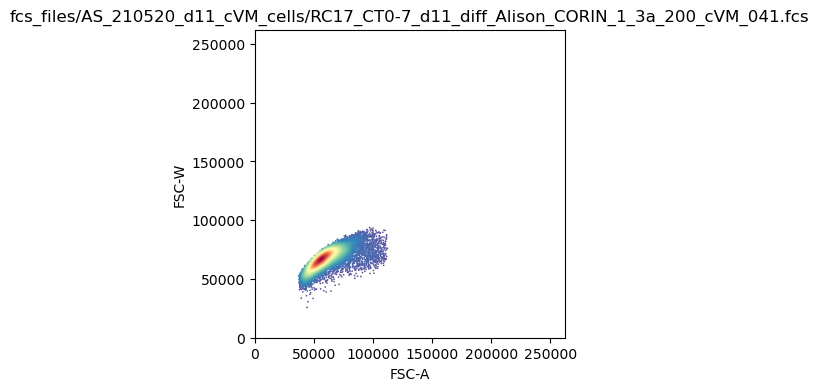

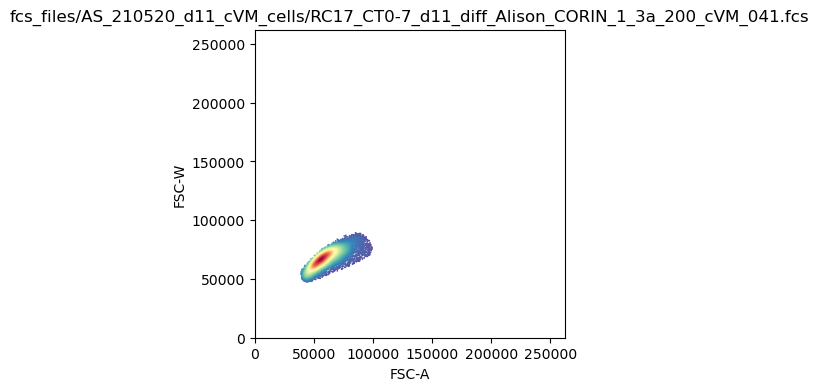

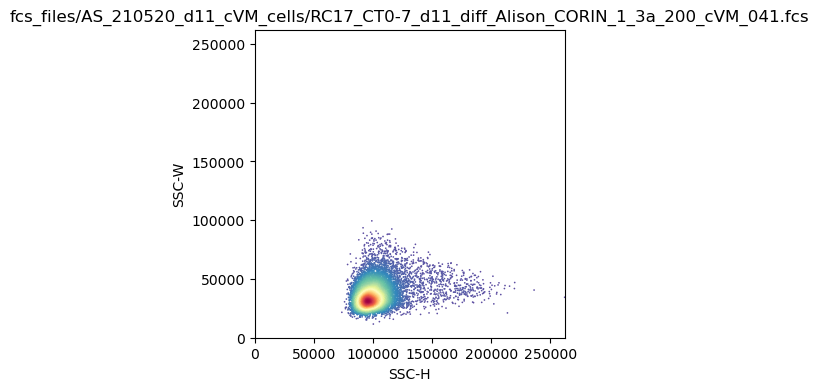

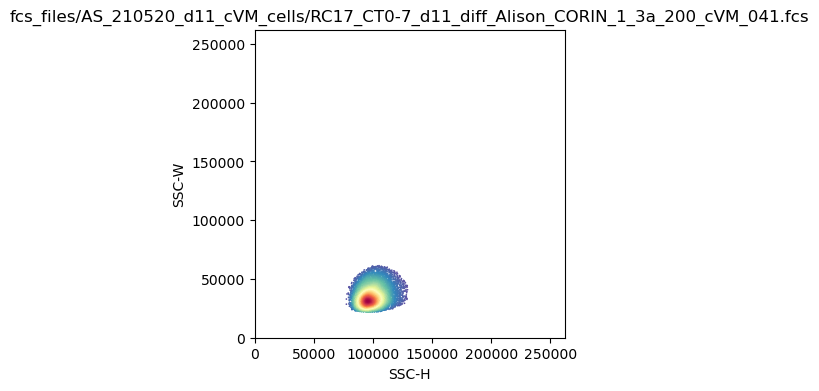

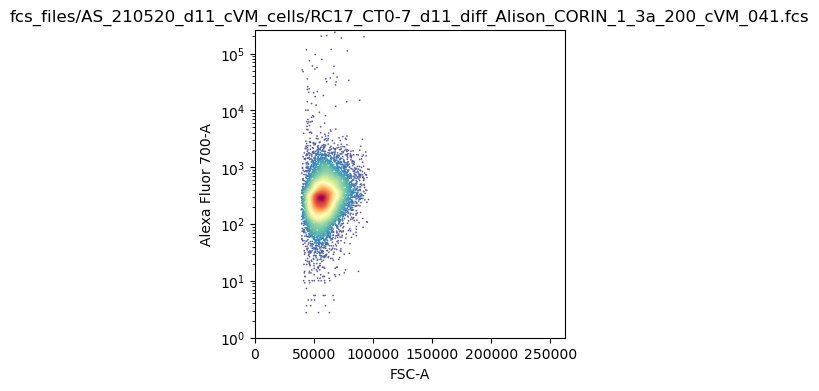

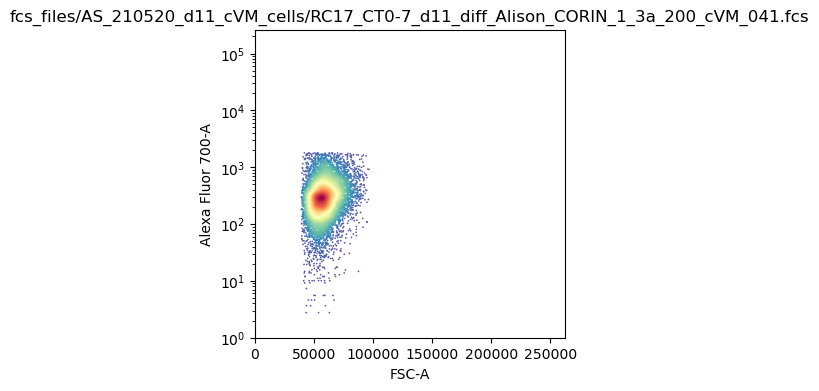

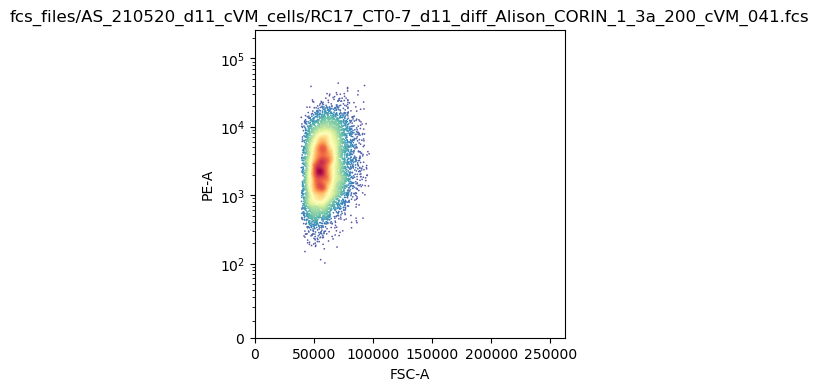

Number of events in gated sample: 8399


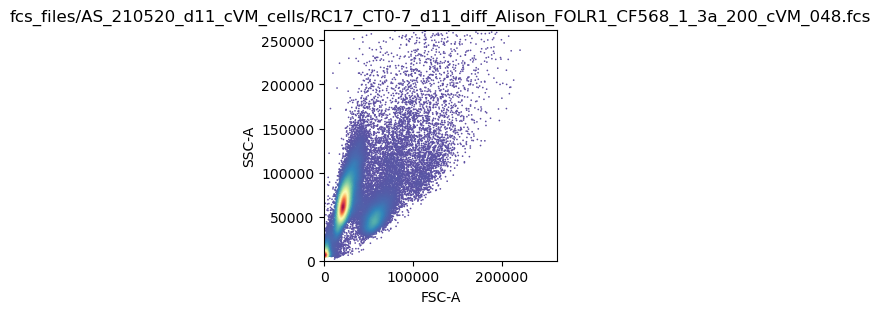

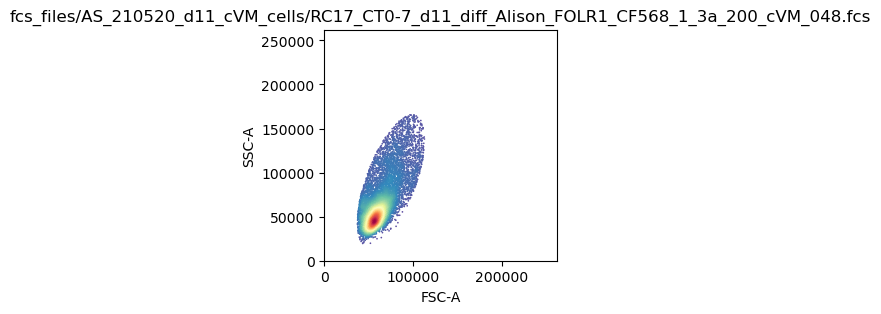

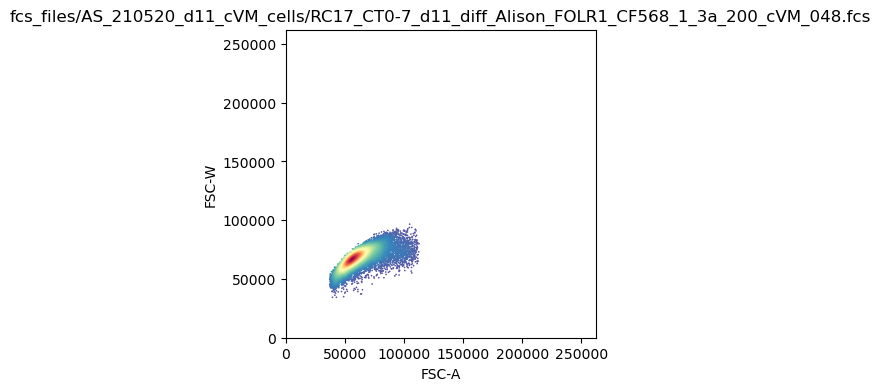

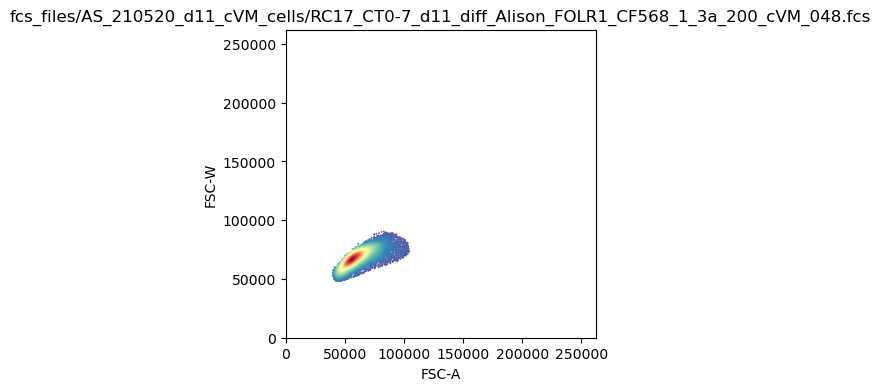

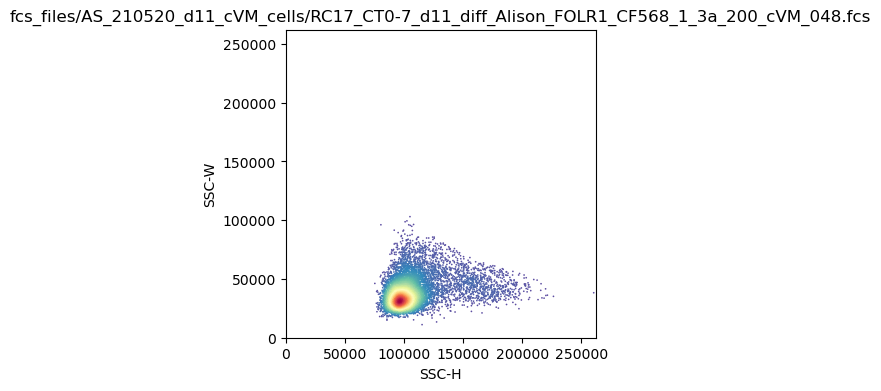

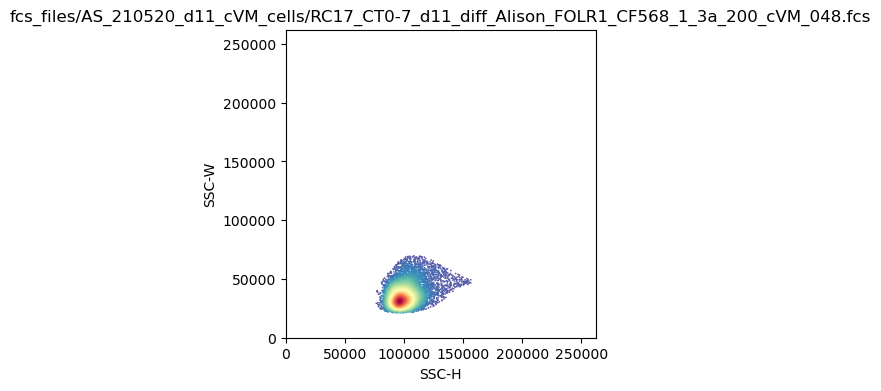

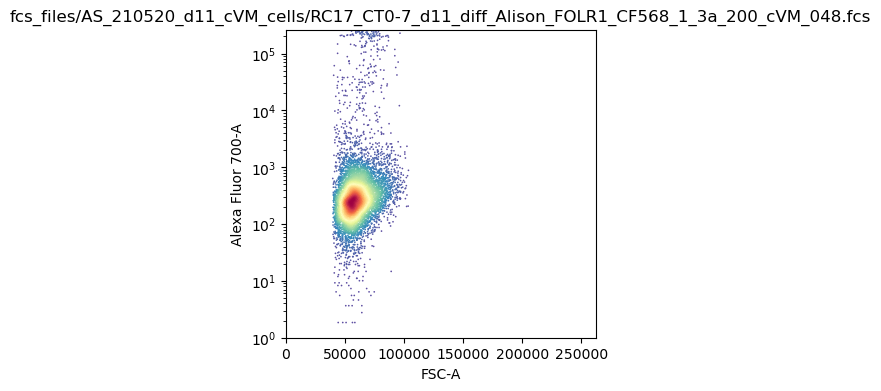

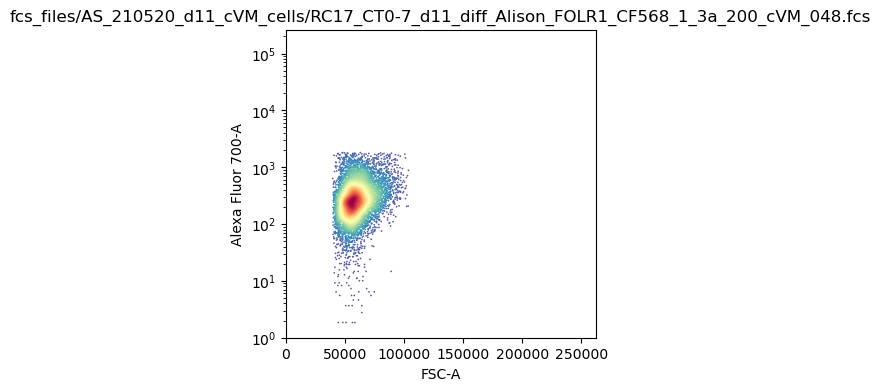

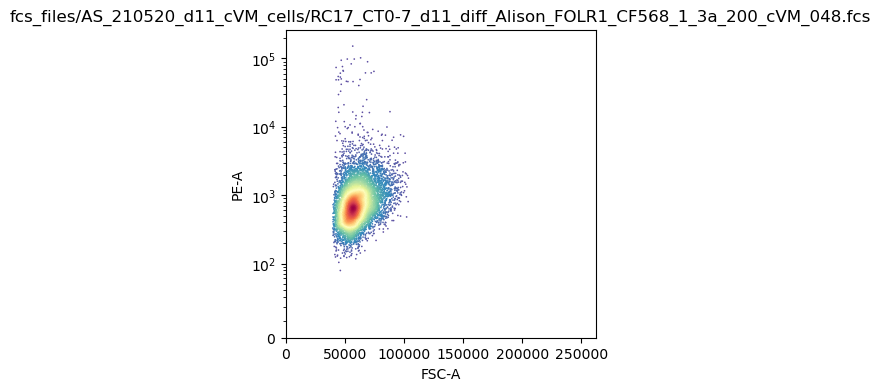

Number of events in gated sample: 7607


In [5]:
#plot
count = 0
for i, (filename, file) in enumerate(imported_files.items()):
    count += 1
    if count > 5:
        break
    
    #plot the fsc-a vs ssc-a
    plt.figure(figsize=(3, 3)) # make the figure wider
    FlowCal.plot.density2d(file, channels=['FSC-A', 'SSC-A'], mode='scatter', yscale = 'linear', xscale='linear')
    plt.title(filename)
    plt.show()


    #gate the data
    s = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], 
                            center=(7.5e4, 9e4), #center (xy coordinates)
                            a=28000, #width
                            b=80000, #height
                            theta=-20/180.*np.pi #rotation
                            )
    
    #plot the cell gate
    plt.figure(figsize=(3, 3))
    FlowCal.plot.density2d(s, channels=['FSC-A','SSC-A'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #evaluate the results of the gating in fsc-a/fsc-w
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','FSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #3.(density) fsc-a gate
    s = FlowCal.gate.density2d(s, channels=['FSC-A','FSC-W'], gate_fraction=0.92)


    #plot the singlets-fsc gate
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','FSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #evaluate the results of the gating in ssc-h/ssc-w
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['SSC-H','SSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #4. (density) singlets-ssc gate
    s = FlowCal.gate.density2d(s, channels=['SSC-H','SSC-W'], gate_fraction=0.86)
    
    #plot the singlets-ssc gate
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['SSC-H','SSC-W'], mode='scatter', xscale='linear', yscale='linear')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #evaluate the results of the gating in draq7
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','Alexa Fluor 700-A'], mode='scatter', xscale='linear', yscale='log')
    plt.title(filename)  # Set the title to the filename
    plt.show()
    
    #5. (threshhold) live gate
    s = FlowCal.gate.high_low(s, channels=['Alexa Fluor 700-A'], high=1800)

    #plot the data 
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','Alexa Fluor 700-A'], mode='scatter', xscale='linear', yscale='log')
    plt.title(filename)  # Set the title to the filename
    plt.show()

    #6. gating in markers of interest    
    #6.1 pe
    #plot the data as density plot
    plt.figure(figsize=(4, 4))
    FlowCal.plot.density2d(s, channels=['FSC-A','PE-A'],  mode='scatter', xscale='linear', yscale='logicle')
    plt.title(filename)  # Set the title to the filename
    plt.show()


    print(f"Number of events in gated sample: {s.shape[0]}")

## Calculate the cut-offs

In [6]:
# calculate relevant metric for the fmo's of the for each fluorophore and folder
fmo_percentiles = {'PE': [], 'AF488': [], 'PE-Cy7': []}
fmo_means = {'PE-Cy7': [], 'AF488': [], 'PE': []} 
fmo_stds =  {'PE-Cy7': [], 'AF488': [], 'PE': []}

for i, (filename, file) in enumerate(imported_files.items()):
    if 'unstained_ctrl' in filename:
        
        #gate the cells
        g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], 
                                  center=(7.5e4, 9e4), #center (xy coordinates)
                                  a=28000, #width
                                  b=80000, #height
                                  theta=-20/180.*np.pi #rotation
                                  )
        g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.90)
        g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.93)
        g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1800)

        #calculate the 99.9th percentile of the fmo's
        if 'PE-vio770' in filename and 'PE-Cy7-A' in g4.channels:
            fmo_percentiles['PE-Cy7'].append(np.percentile(g4[:, 'PE-Cy7-A'], 99.9))
            fmo_means['PE-Cy7'].append(np.mean(g4[:, 'PE-Cy7-A']))
            fmo_stds['PE-Cy7'].append(np.std(g4[:, 'PE-Cy7-A']))
        elif 'AF488' in filename and 'Alexa Fluor 488-A' in g4.channels:
            fmo_percentiles['AF488'].append(np.percentile(g4[:, 'Alexa Fluor 488-A'], 99.9))
            fmo_means['AF488'].append(np.mean(g4[:, 'Alexa Fluor 488-A']))
            fmo_stds['AF488'].append(np.std(g4[:, 'Alexa Fluor 488-A']))
        elif 'PE-A' in g4.channels:
            fmo_percentiles['PE'].append(np.percentile(g4[:, 'PE-A'], 99.9))
            fmo_means['PE'].append(np.mean(g4[:, 'PE-A']))
            fmo_stds['PE'].append(np.std(g4[:, 'PE-A']))

# retrieve the relevant metrics for each fluorophore, separately for each folder and fluorophore
perc_cutoffs = {k: np.mean(v) for k, v in fmo_percentiles.items()}
mean_of_means = {k: np.mean(v) for k, v in fmo_means.items()}
mean_of_stds = {k: np.mean(v) for k, v in fmo_stds.items()}
std_cutoffs_3 = {k: mean + 3*std for k, mean, std in zip(mean_of_means.keys(), mean_of_means.values(), mean_of_stds.values())}

print(f"99.9th% cutoffs:\n {perc_cutoffs}")
print(f"Mean+3SD cutoffs:\n {std_cutoffs_3}")

99.8th% cutoffs:
 {'PE': 518.3672428550818, 'AF488': 747.5841513824522, 'PE-Cy7': 1075.0481914672916}
Mean+3SD cutoffs:
 {'PE-Cy7': 607.3631591796875, 'AF488': 358.1949691772461, 'PE': 306.94097900390625}


### Apply the cut-offs to test

Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_Alison_ALCAM_1_3a_100_cVM_038.fcs


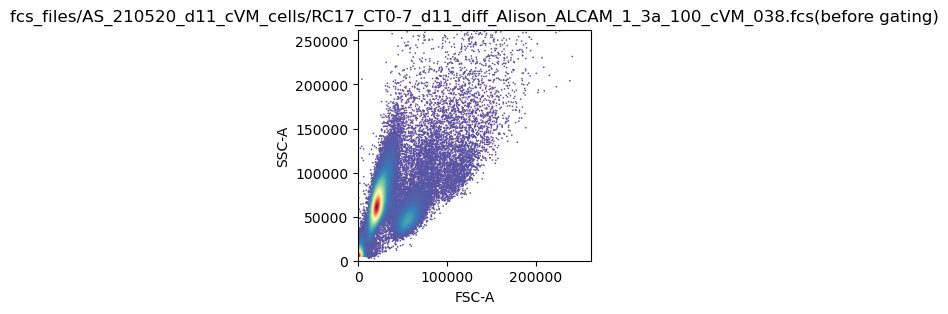

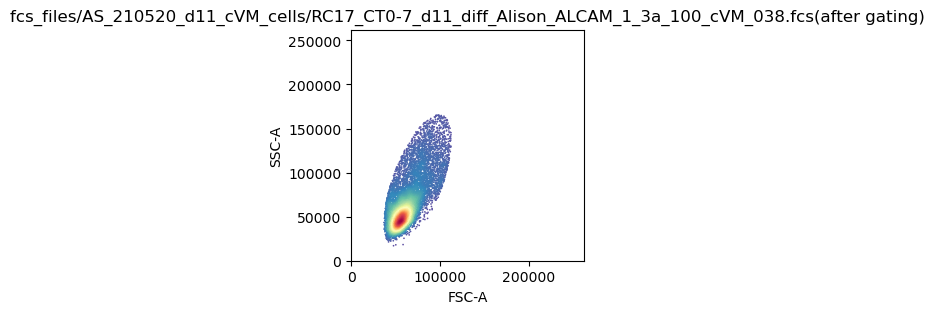

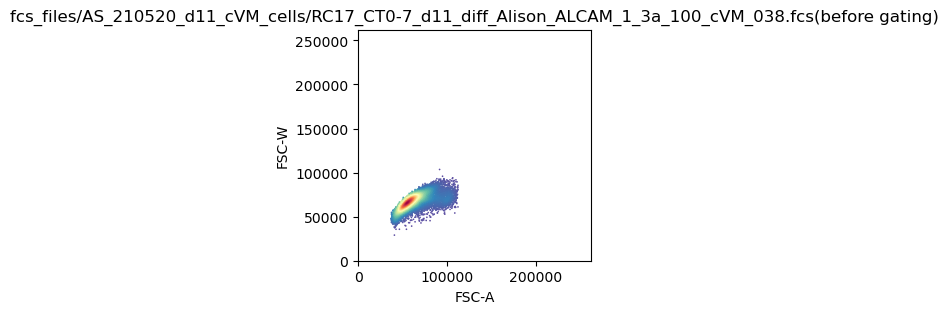

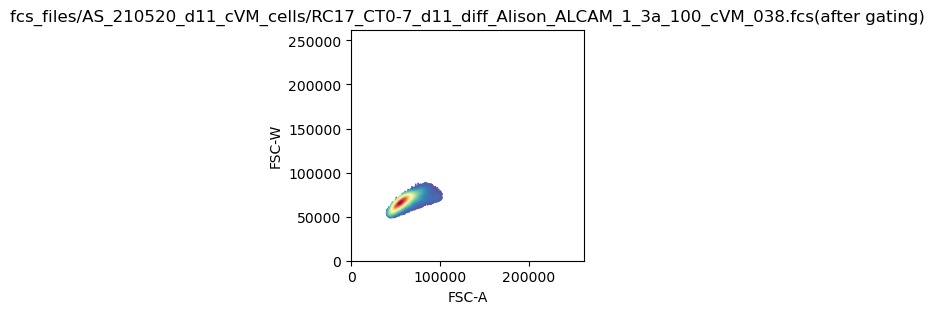

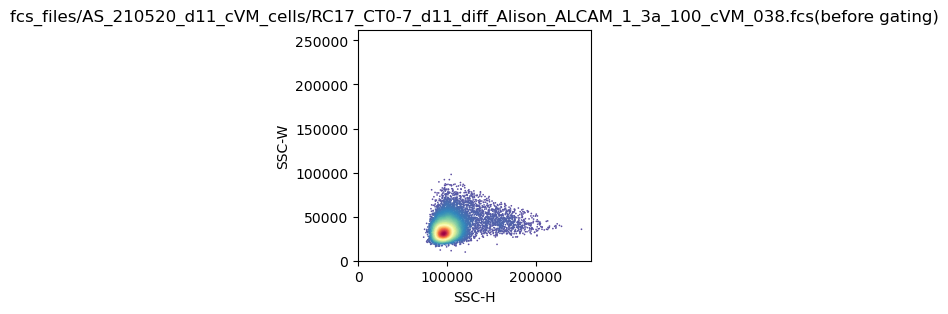

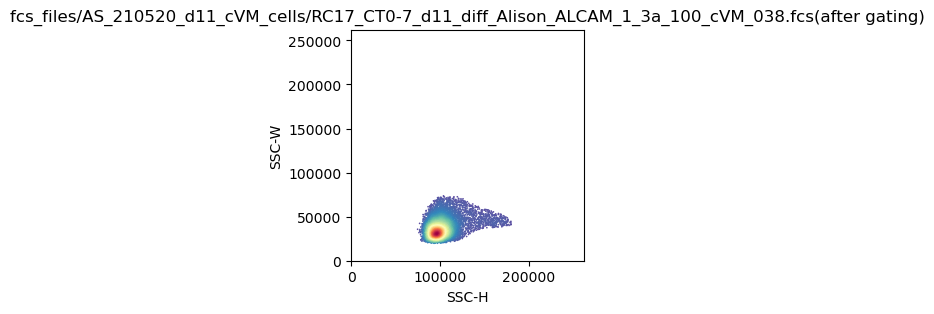

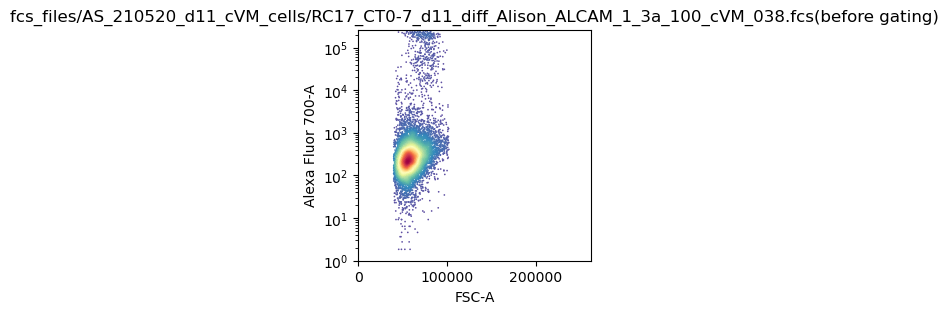

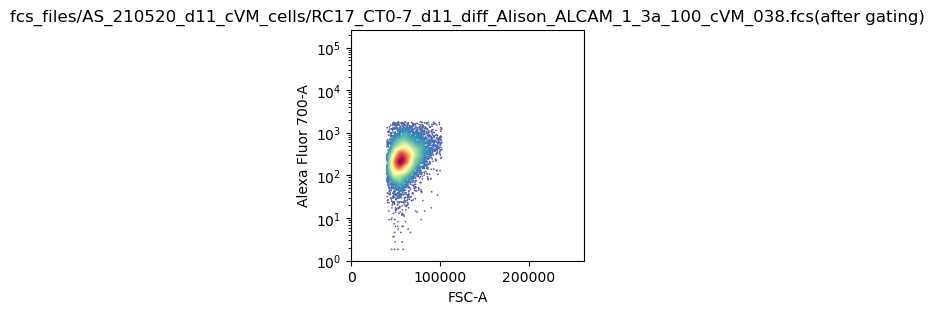

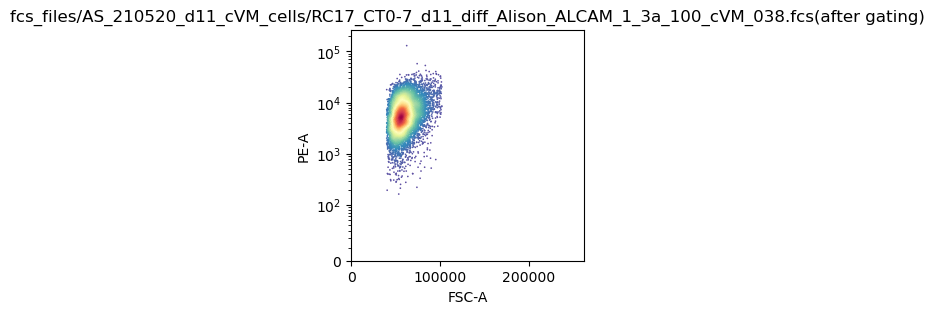

Applying gate on PE-A with cutoff 1075.0481914672916 (inverse=True)
Initial count: 8661, Final count after gating: 8478, Percentage retained: 97.89%


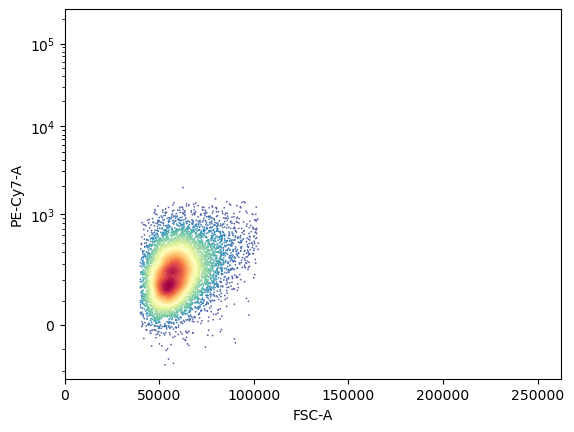

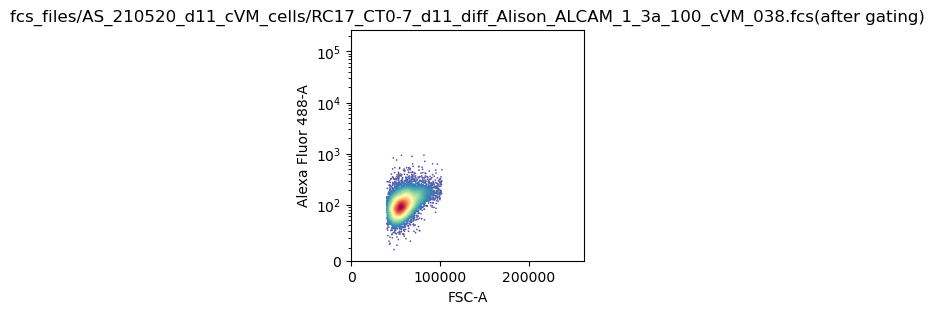

Applying gate on Alexa Fluor 488-A with cutoff 747.5841513824522 (inverse=True)
Initial count: 8661, Final count after gating: 5, Percentage retained: 0.06%


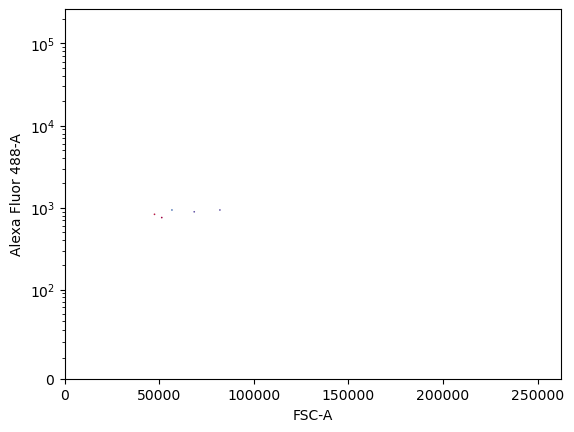

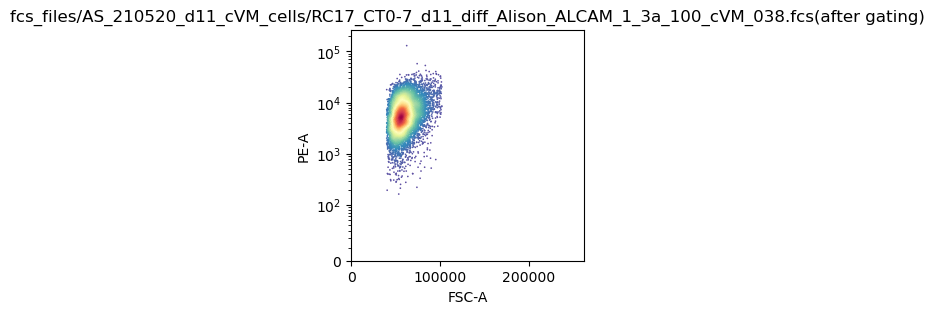

Applying gate on PE-A with cutoff 518.3672428550818 (inverse=True)
Initial count: 8661, Final count after gating: 8624, Percentage retained: 99.57%
Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_Alison_APCDD1_1_3a_100_cVM_039.fcs


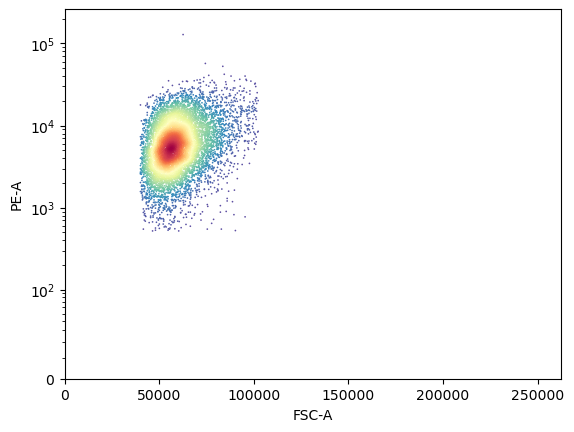

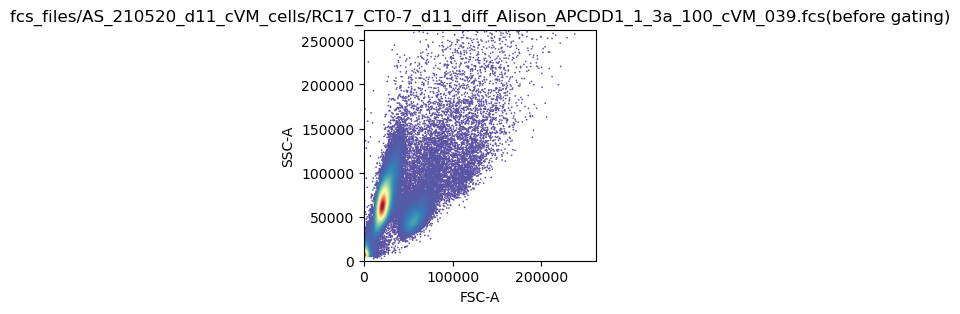

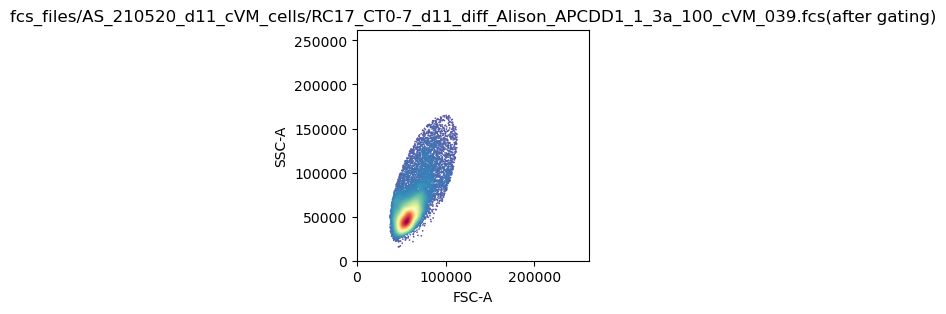

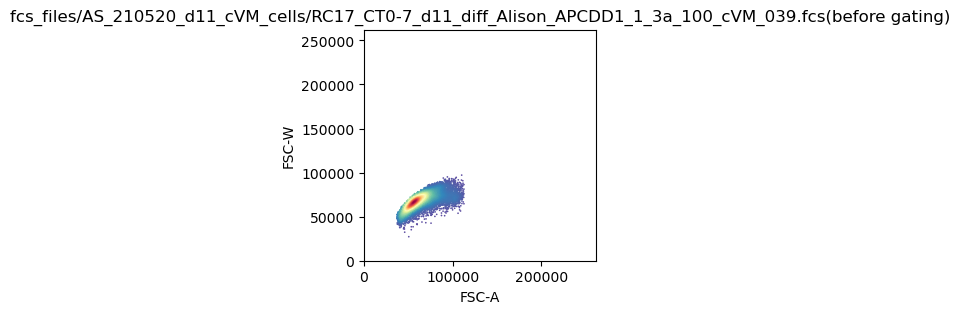

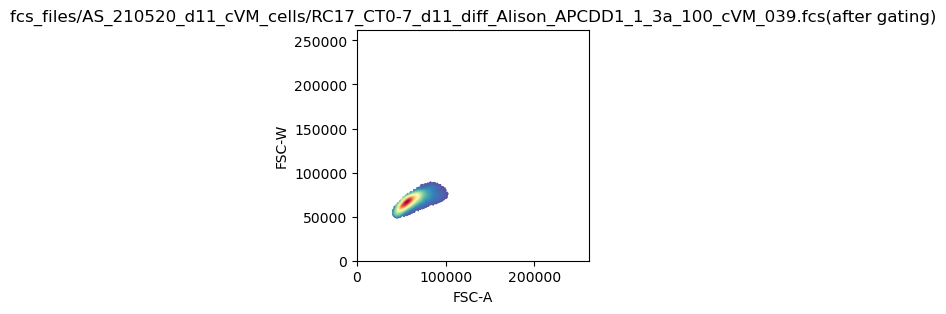

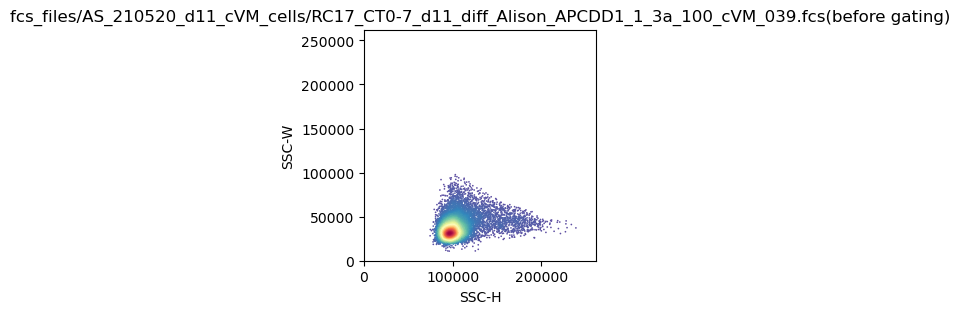

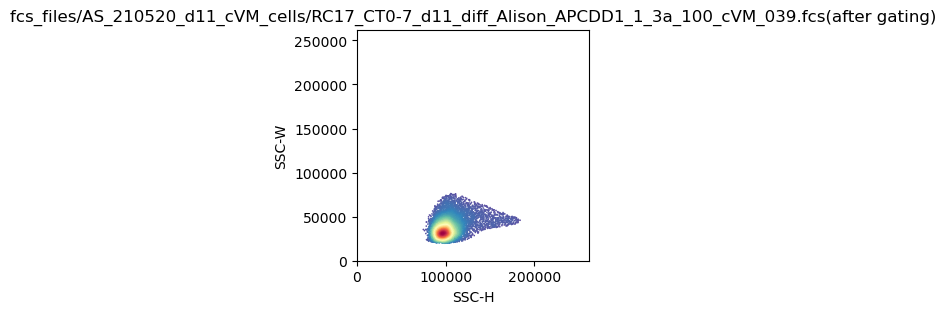

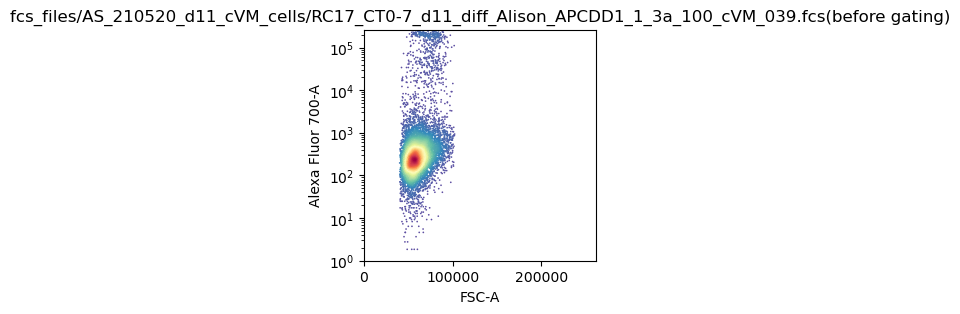

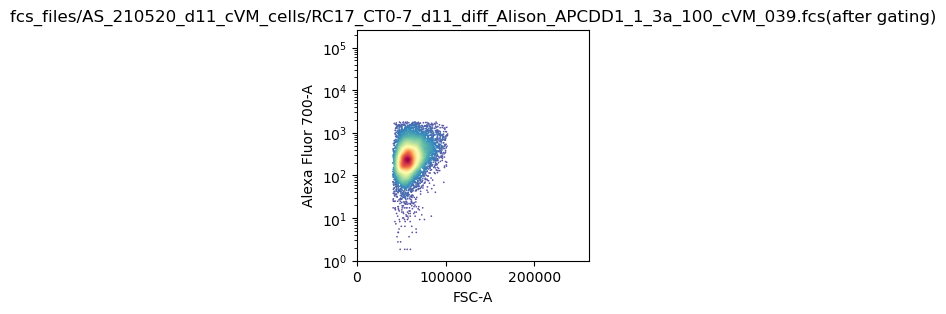

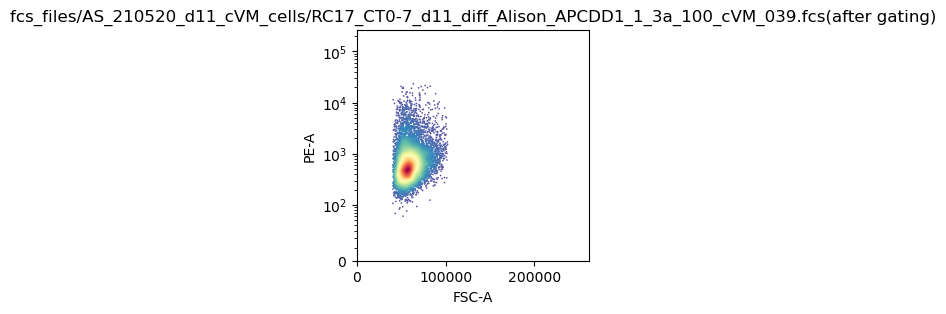

Applying gate on PE-A with cutoff 1075.0481914672916 (inverse=True)
Initial count: 8574, Final count after gating: 2000, Percentage retained: 23.33%


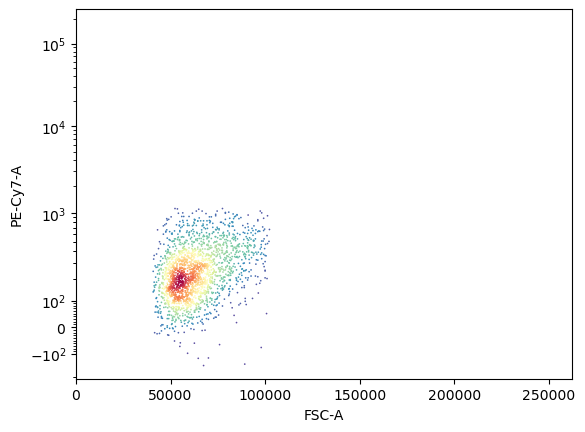

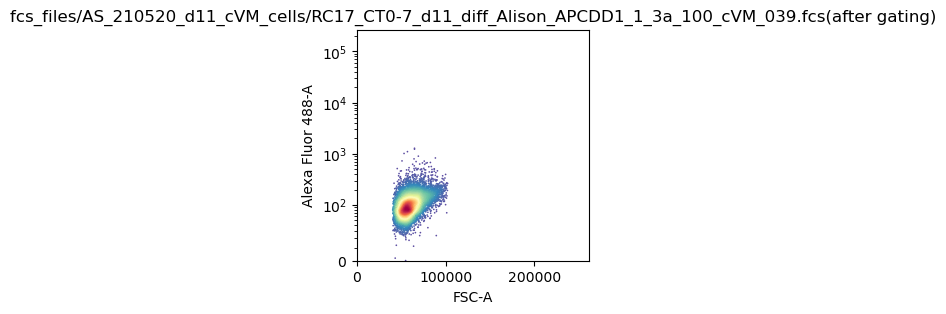

Applying gate on Alexa Fluor 488-A with cutoff 747.5841513824522 (inverse=True)
Initial count: 8574, Final count after gating: 7, Percentage retained: 0.08%


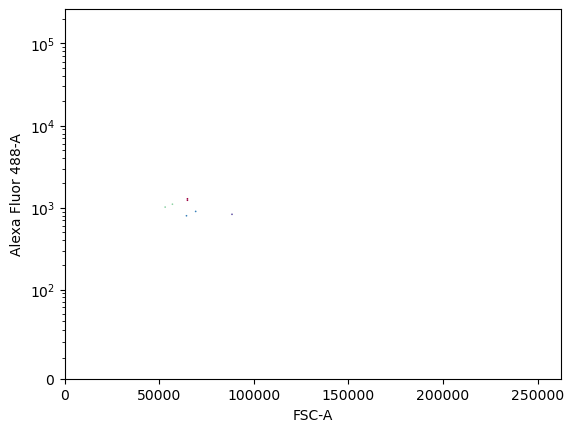

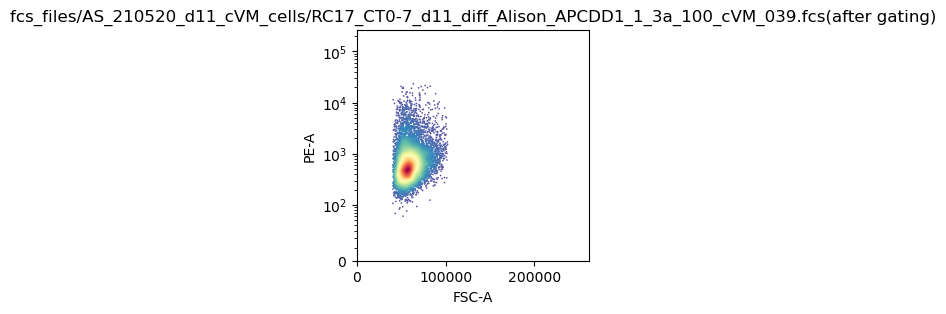

Applying gate on PE-A with cutoff 518.3672428550818 (inverse=True)
Initial count: 8574, Final count after gating: 5355, Percentage retained: 62.46%
Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_Alison_CNTN2_1_3a_20_cVM_040.fcs


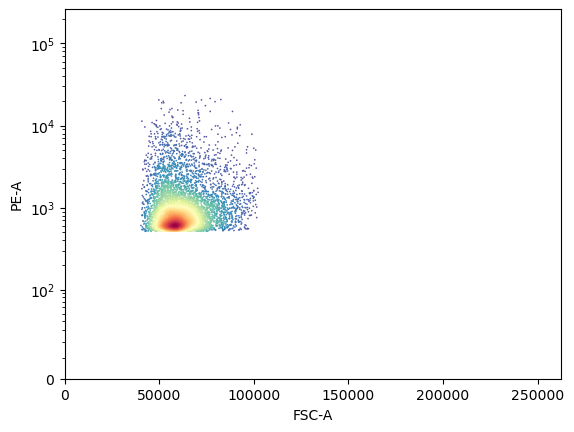

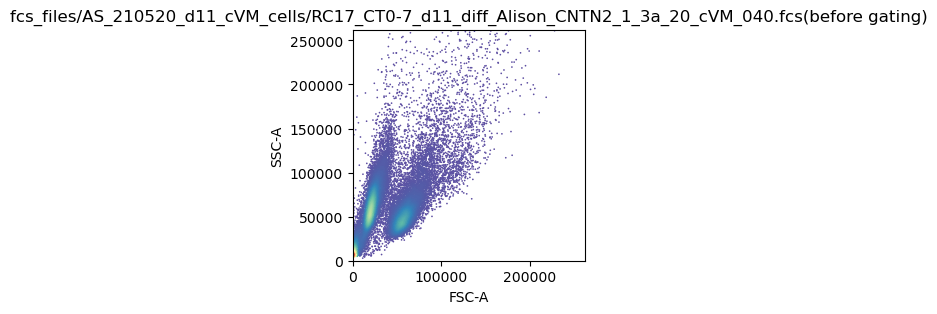

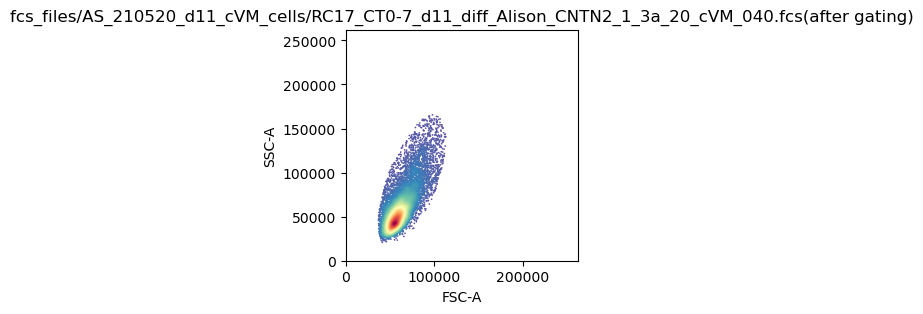

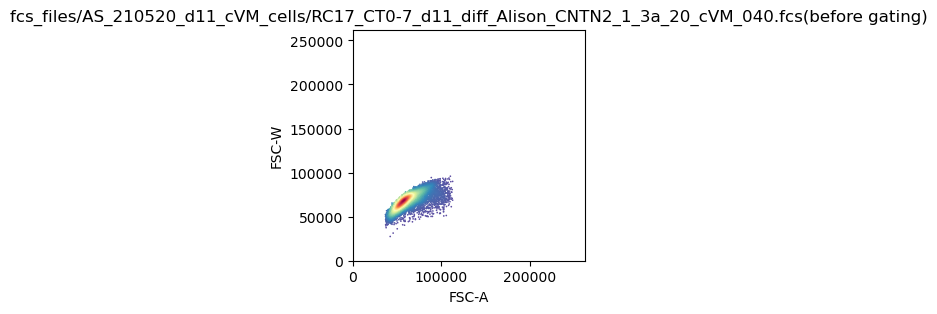

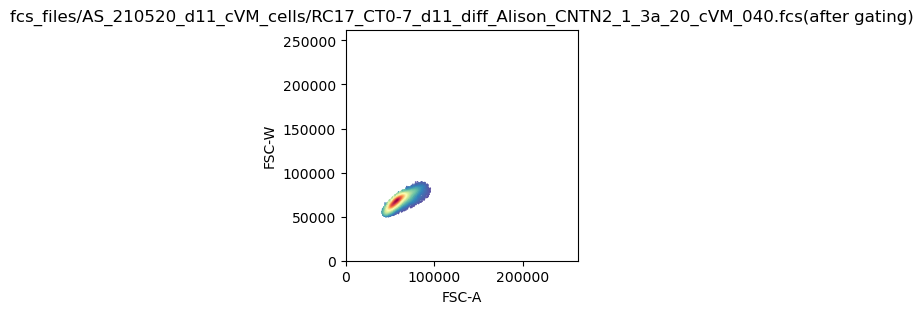

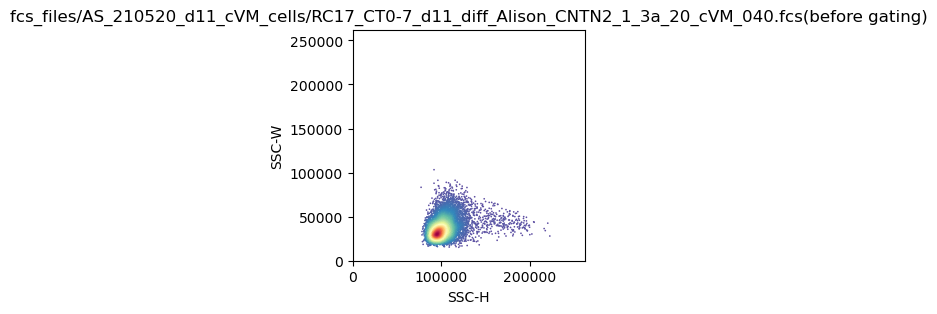

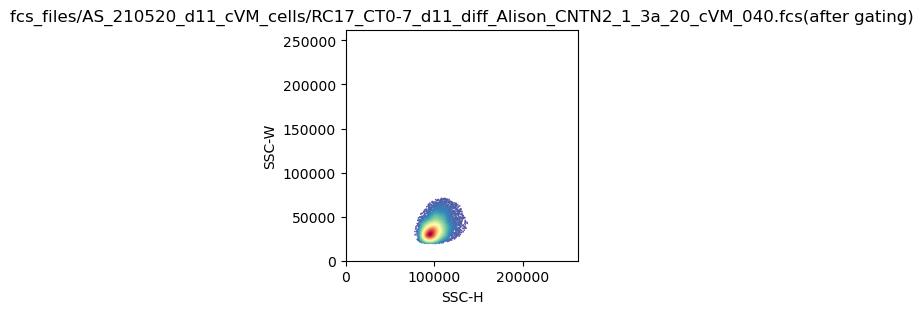

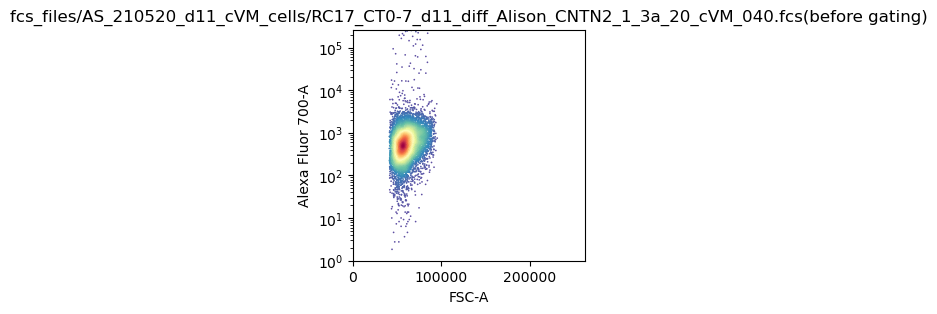

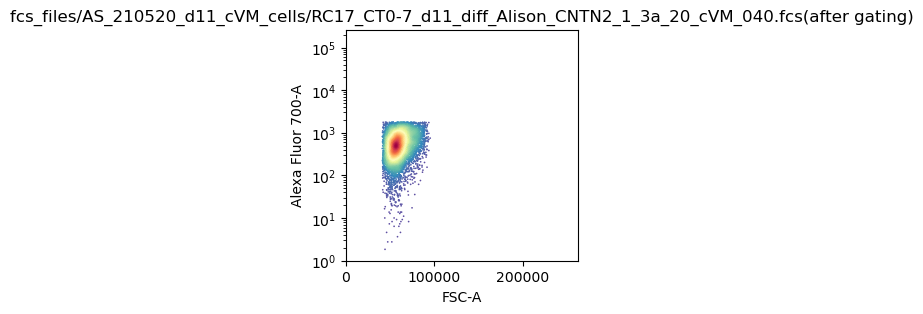

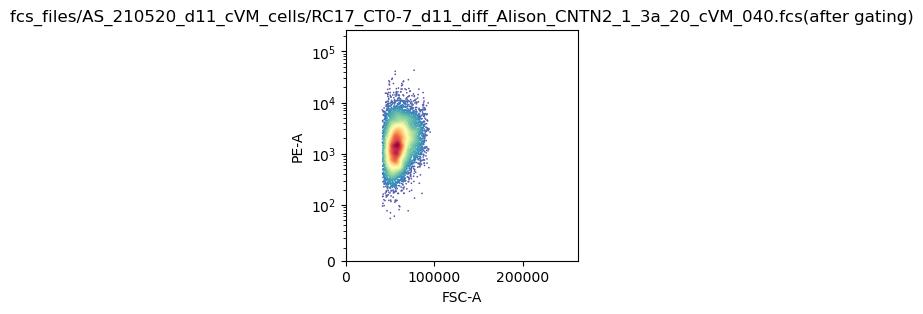

Applying gate on PE-A with cutoff 1075.0481914672916 (inverse=True)
Initial count: 7861, Final count after gating: 5369, Percentage retained: 68.3%


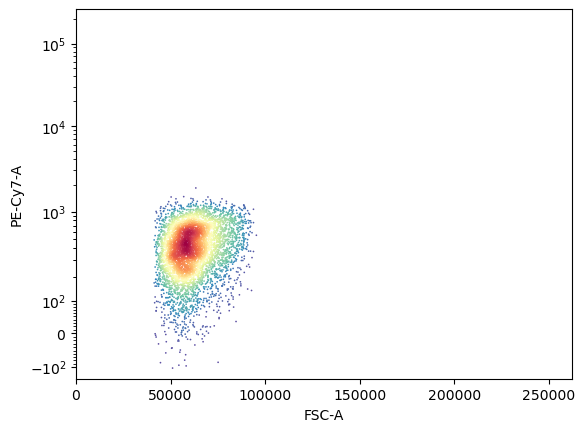

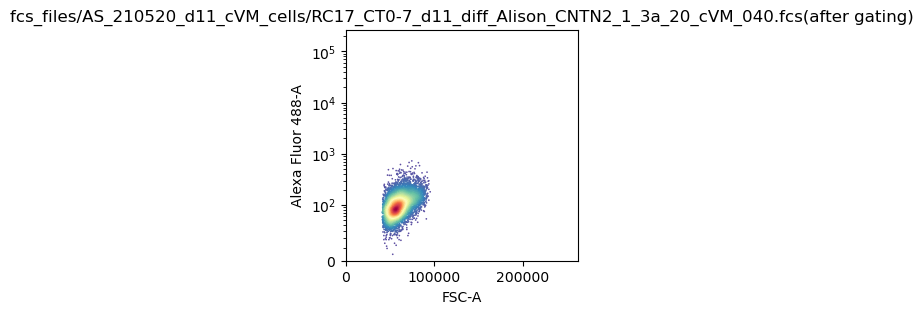

Applying gate on Alexa Fluor 488-A with cutoff 747.5841513824522 (inverse=True)
Initial count: 7861, Final count after gating: 0, Percentage retained: 0.0%


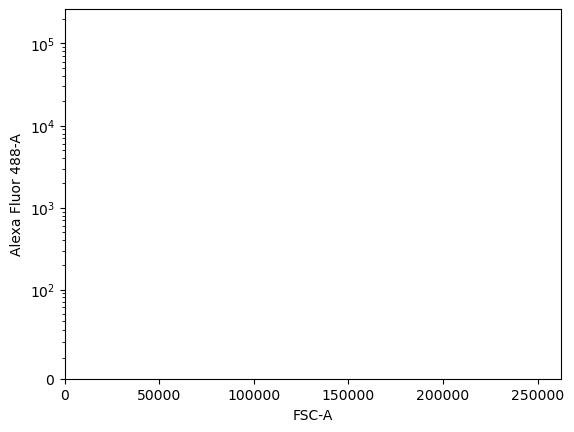

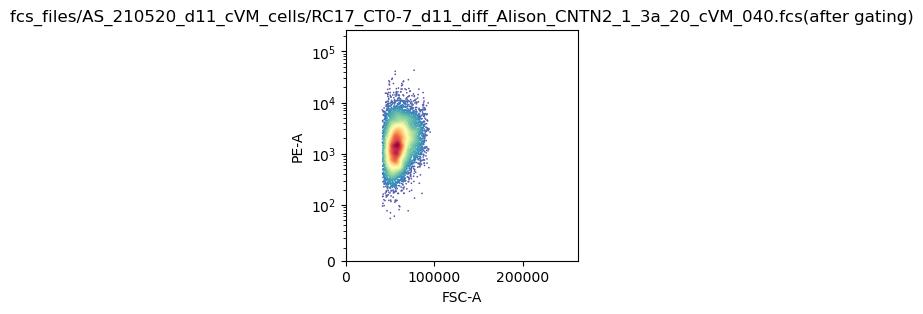

Applying gate on PE-A with cutoff 518.3672428550818 (inverse=True)
Initial count: 7861, Final count after gating: 7218, Percentage retained: 91.82%
Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_Alison_CORIN_1_3a_200_cVM_041.fcs


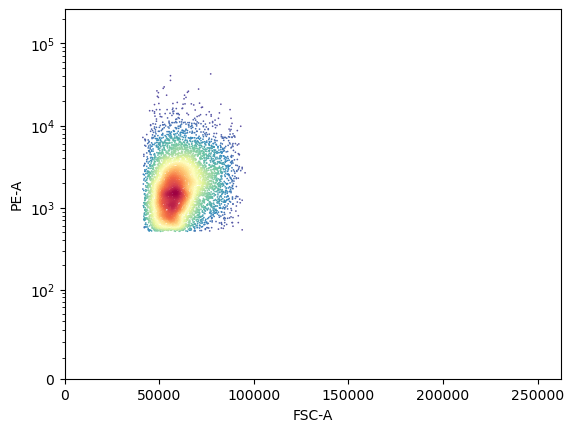

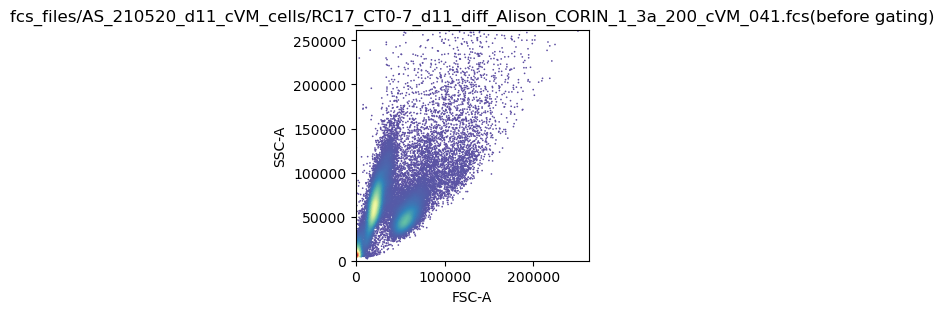

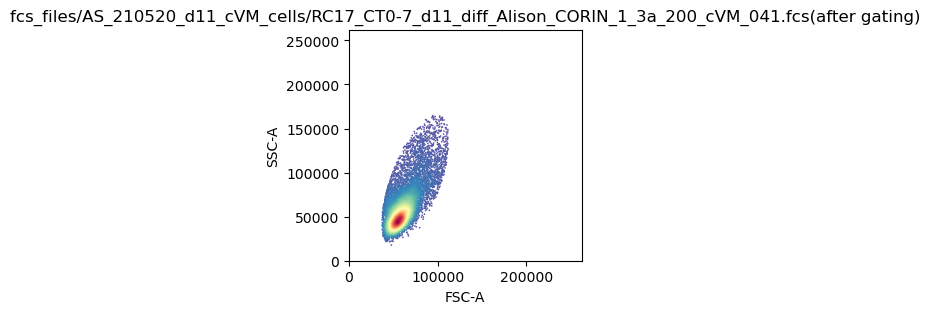

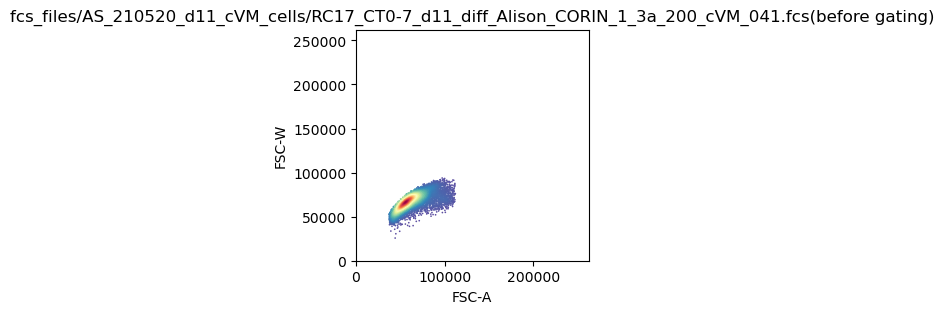

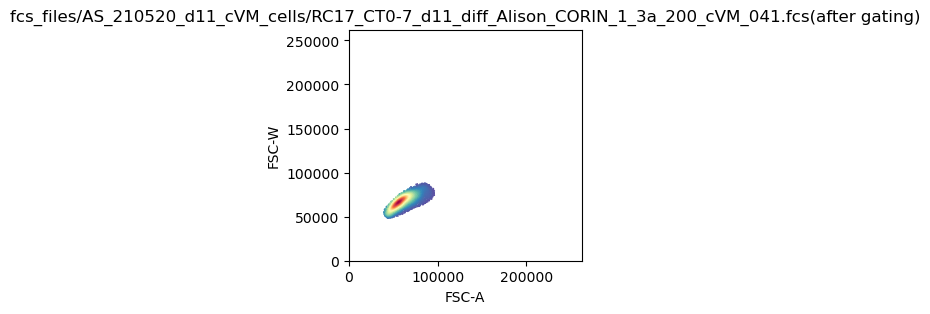

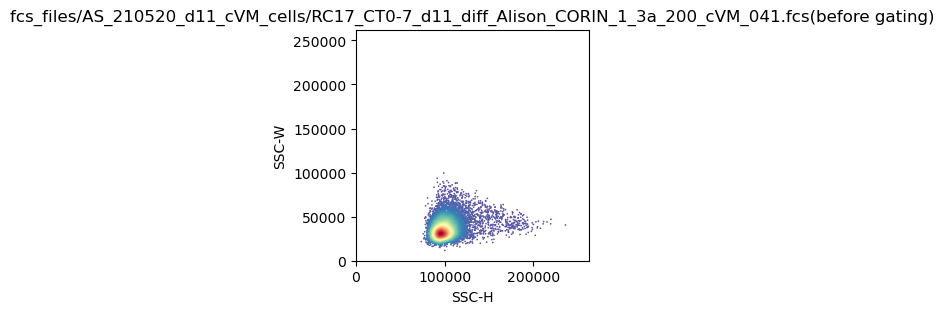

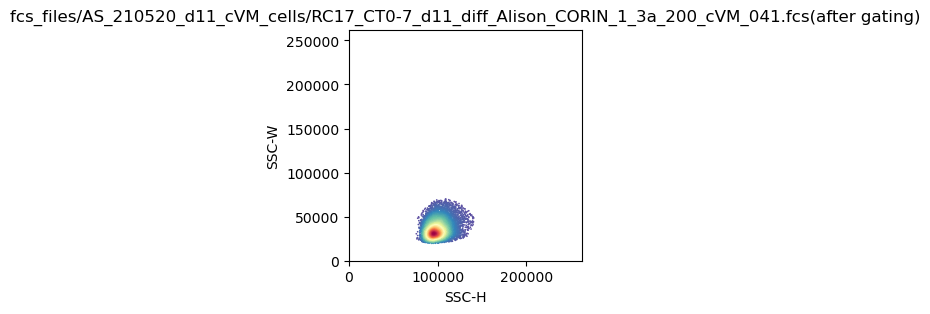

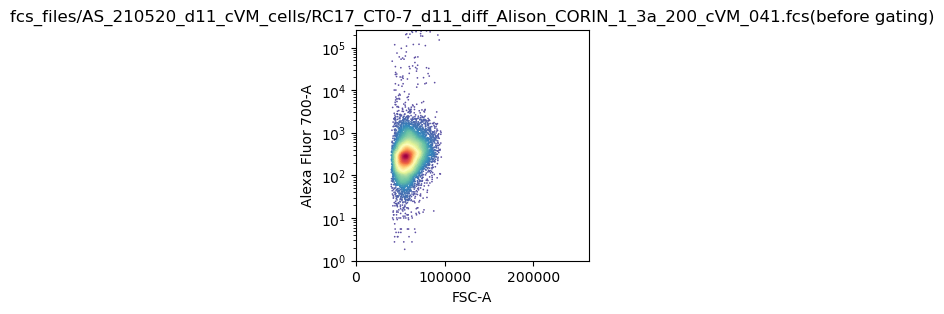

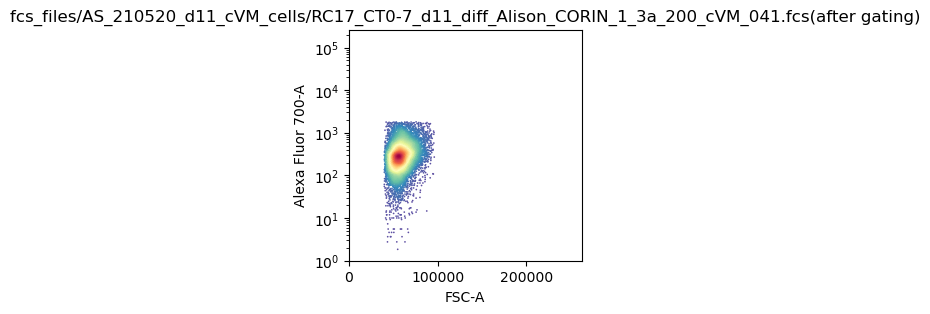

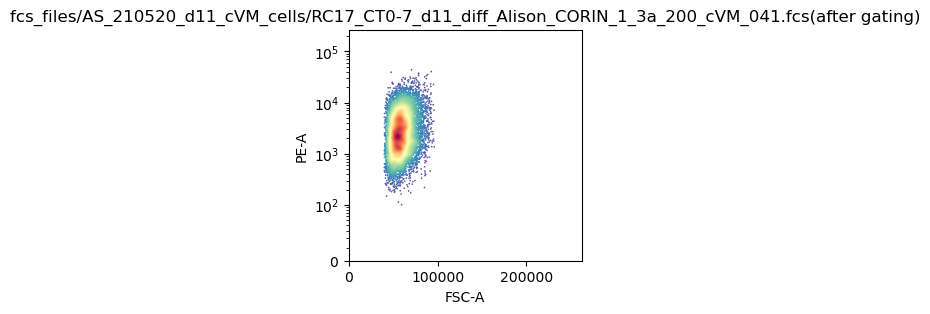

Applying gate on PE-A with cutoff 1075.0481914672916 (inverse=True)
Initial count: 8822, Final count after gating: 7275, Percentage retained: 82.46%


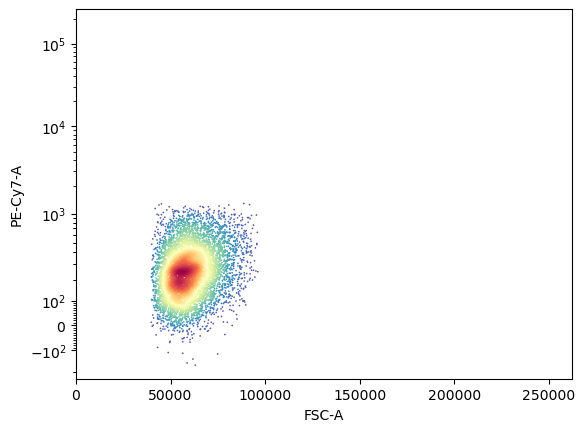

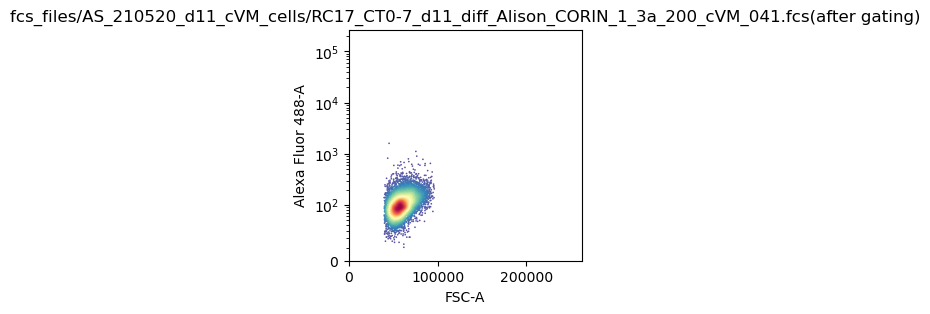

Applying gate on Alexa Fluor 488-A with cutoff 747.5841513824522 (inverse=True)
Initial count: 8822, Final count after gating: 6, Percentage retained: 0.07%


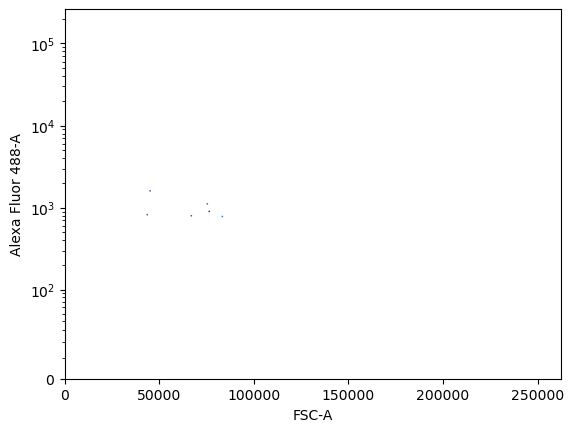

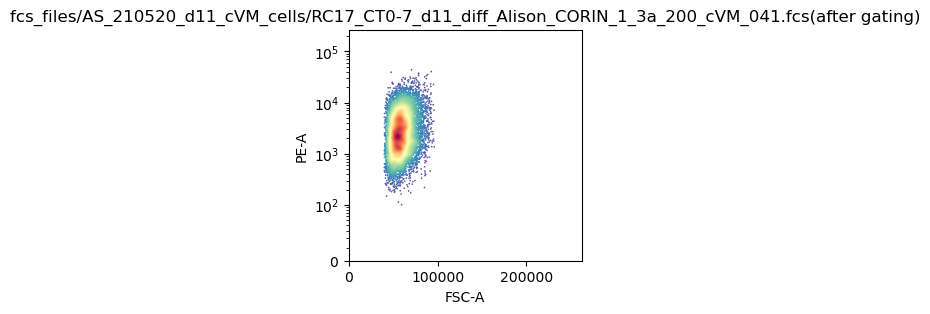

Applying gate on PE-A with cutoff 518.3672428550818 (inverse=True)
Initial count: 8822, Final count after gating: 8508, Percentage retained: 96.44%
Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_Alison_FOLR1_CF568_1_3a_200_cVM_048.fcs


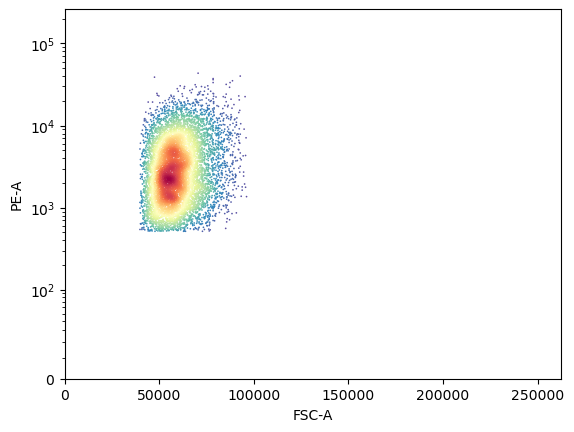

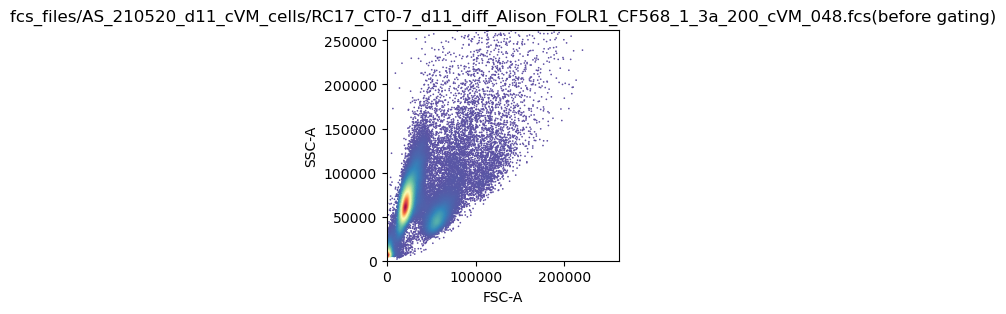

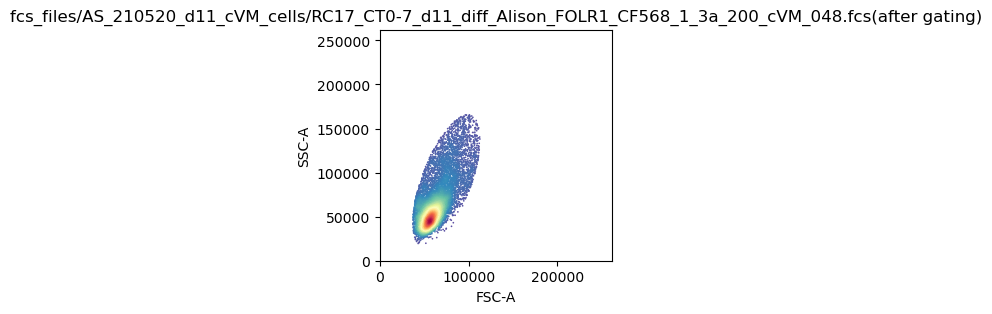

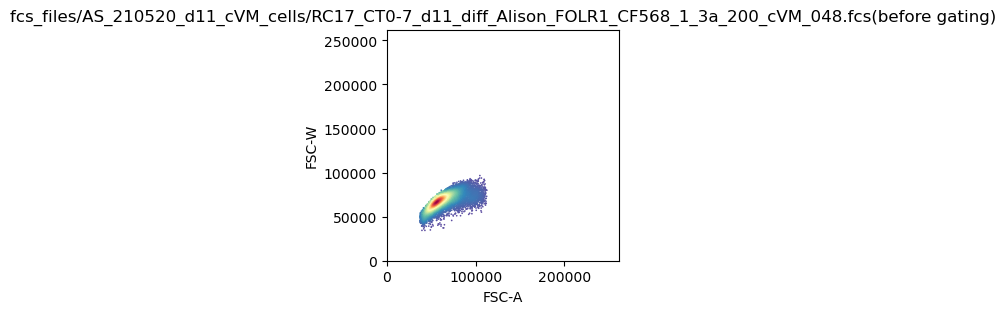

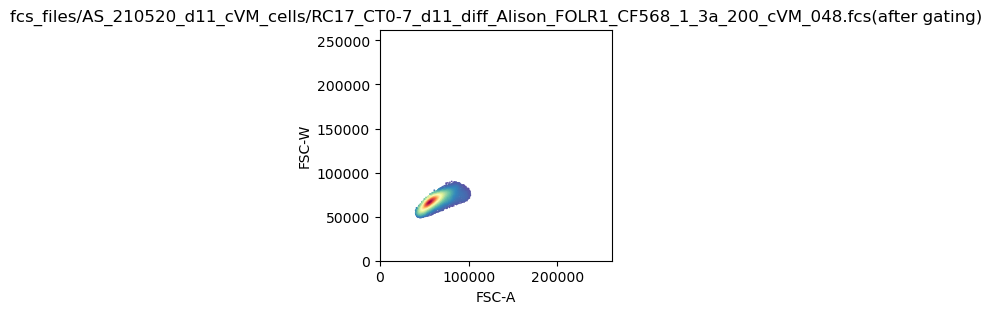

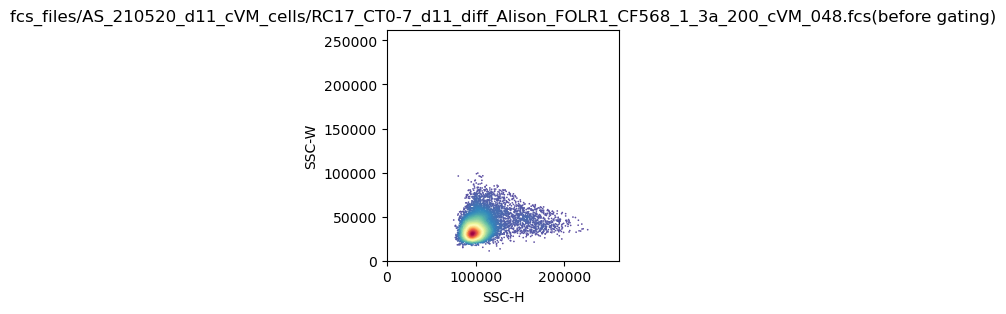

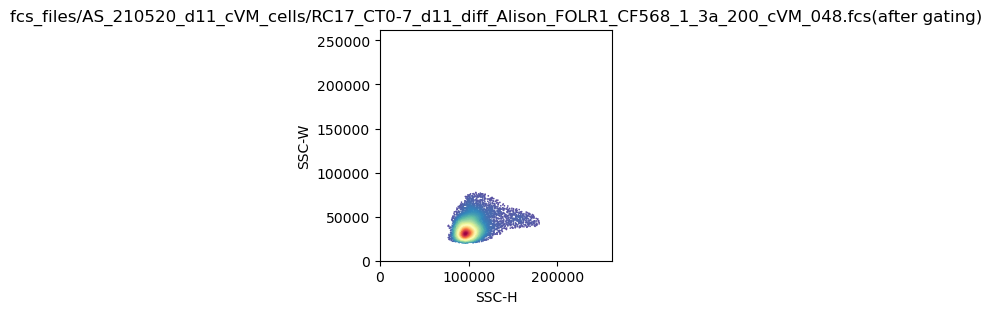

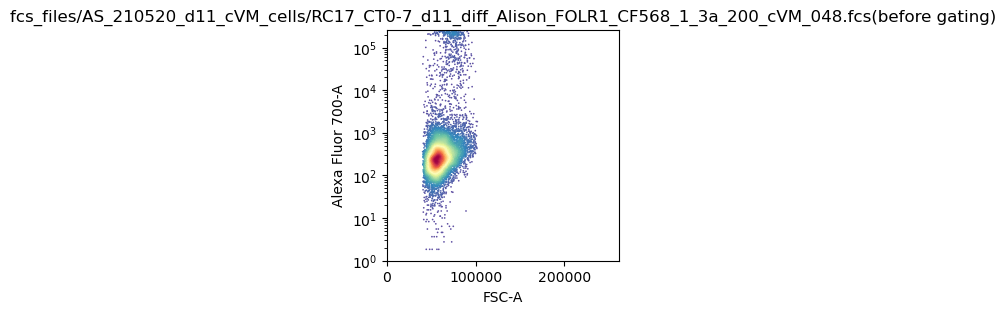

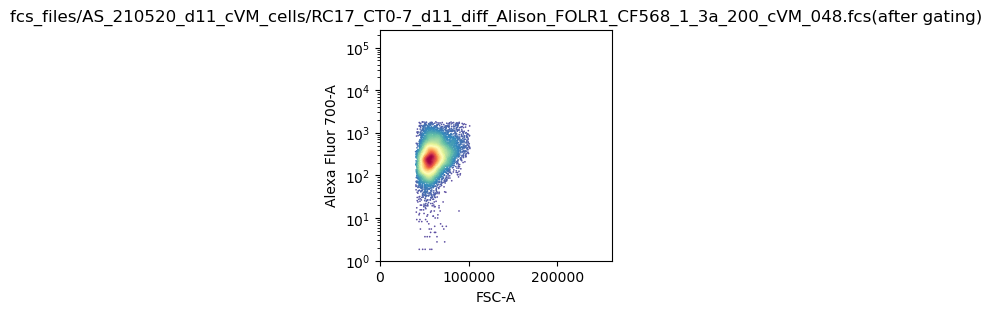

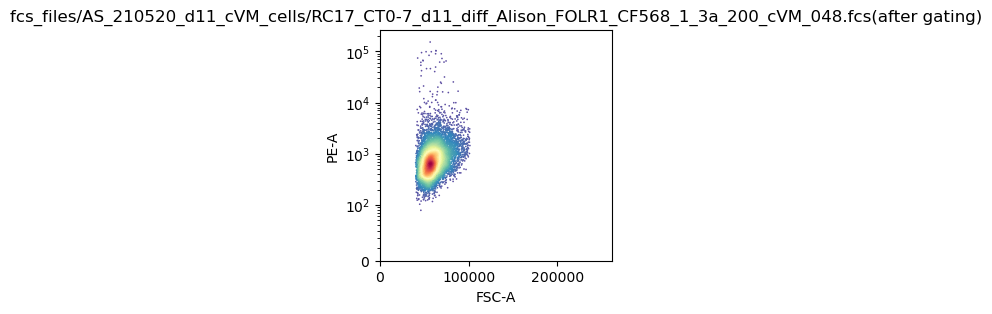

Applying gate on PE-A with cutoff 1075.0481914672916 (inverse=True)
Initial count: 7769, Final count after gating: 2233, Percentage retained: 28.74%


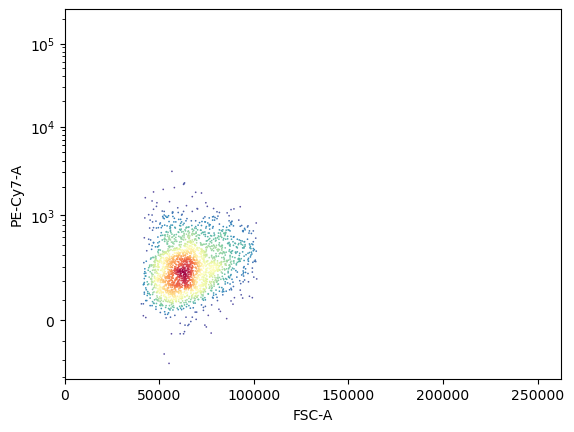

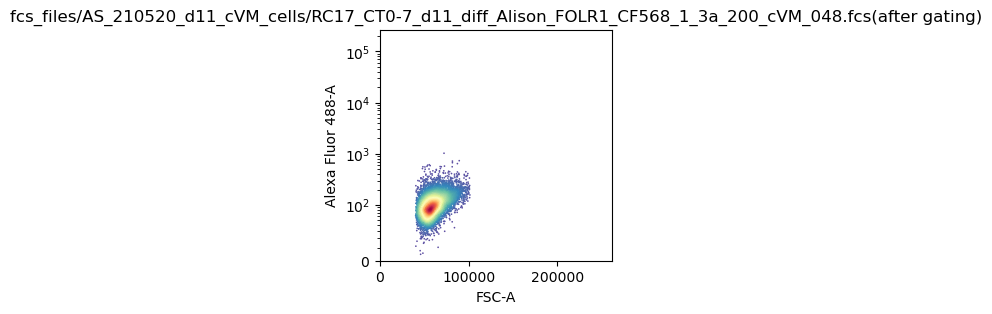

Applying gate on Alexa Fluor 488-A with cutoff 747.5841513824522 (inverse=True)
Initial count: 7769, Final count after gating: 1, Percentage retained: 0.01%


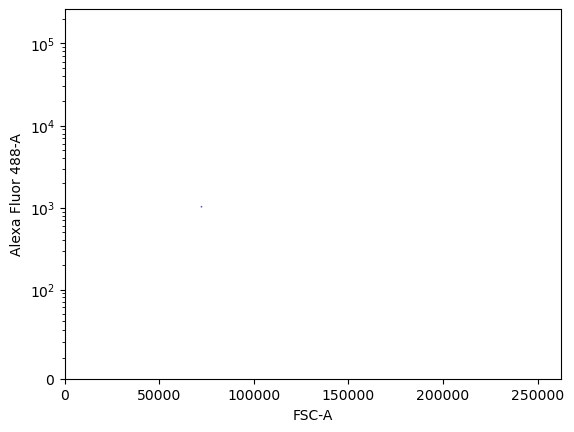

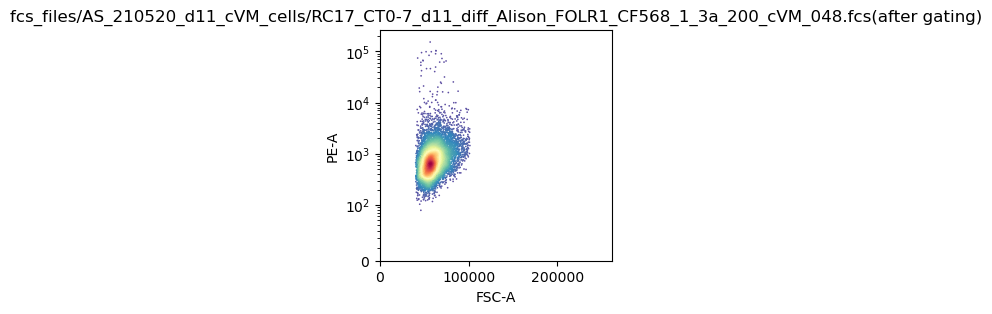

Applying gate on PE-A with cutoff 518.3672428550818 (inverse=True)
Initial count: 7769, Final count after gating: 5665, Percentage retained: 72.92%
Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_Alison_IAP_1_3a_50_cVM_046.fcs


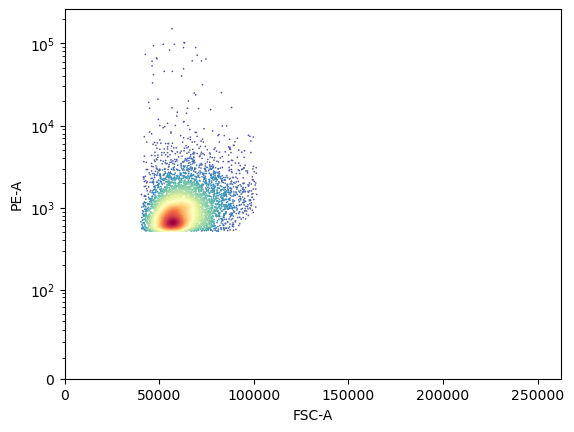

In [7]:
def plot_and_gate(g, channels, title, mode='scatter', xscale='linear', yscale='linear', gate=None, cutoff=None, inverse=False):
    plt.figure(figsize=(3, 3))
    FlowCal.plot.density2d(g, channels=channels, mode=mode, xscale=xscale, yscale=yscale)
    plt.title(title)
    plt.show()

    if gate and cutoff is not None:
        print(f"Applying gate on {channels[1]} with cutoff {cutoff} (inverse={inverse})")
        initial_count = g.shape[0]
        if inverse:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], low=cutoff)
        else:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], high=cutoff)
        final_count = g.shape[0]
        print(f"Initial count: {initial_count}, Final count after gating: {final_count}, Percentage retained: {round((final_count / initial_count) * 100, 2)}%")

    return g

#channel-cutoff mapping
channel_to_cutoff_key = {'PE-A': 'PE', 'Alexa Fluor 488-A': 'AF488', 'PE-Cy7-A': 'PE-Cy7'}

# plot and gate the data
count = 0
for i, (filename, file) in enumerate(imported_files.items()):
    print(f'Processing... {filename}')
    count += 1
    if count >= 6:
        break

    plot_and_gate(file, ['FSC-A','SSC-A'], filename + '(before gating)')
    g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], 
                              center=(7.5e4, 9e4), #center (xy coordinates)
                              a=28000, #width
                              b=80000, #height
                              theta=-20/180.*np.pi #rotation
                              )
    plot_and_gate(g1, ['FSC-A','SSC-A'], filename + '(after gating)')
    plot_and_gate(g1, ['FSC-A','FSC-W'], filename + '(before gating)')
    if g1.shape[0] <= 1:
        print(f"Skipping sample {filename} as it has <2 events after fsc-singlets gating.")
        continue
    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.90)
    plot_and_gate(g2, ['FSC-A','FSC-W'], filename + '(after gating)')
    plot_and_gate(g2, ['SSC-H','SSC-W'], filename + '(before gating)')
    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.93)
    plot_and_gate(g3, ['SSC-H','SSC-W'], filename + '(after gating)')
    plot_and_gate(g3, ['FSC-A','Alexa Fluor 700-A'], filename + '(before gating)', yscale='log')
    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1800)
    plot_and_gate(g4, ['FSC-A','Alexa Fluor 700-A'], filename + '(after gating)', yscale='log')

    #apply the gating for the relevant markers
    #include if else statements to check if the channels are present in the file
    #5.1. pe-cy7 gate
    if 'PE-Cy7-A' in g4.channels:
        g5_pe_cy7 = plot_and_gate(g4, ['FSC-A', 'PE-A'], filename + '(after gating)', yscale='logicle', gate=True, cutoff=perc_cutoffs['PE-Cy7'], inverse=True)
        FlowCal.plot.density2d(g5_pe_cy7, channels=['FSC-A', 'PE-Cy7-A'], mode='scatter', xscale='linear', yscale='logicle')
        pe_cy7_gate_events = g5_pe_cy7.shape[0]
    else:
        print(f"Channel PE-Cy7-A not found in file {filename}. Skipping PE-Cy7-A gate.")
        pe_cy7_gate_events = None
    
    #5.2. af488 gate
    if 'Alexa Fluor 488-A' in g4.channels:
        g5_af488 = plot_and_gate(g4, ['FSC-A', 'Alexa Fluor 488-A'], filename + '(after gating)', yscale='logicle', gate=True, cutoff=perc_cutoffs['AF488'], inverse=True)
        FlowCal.plot.density2d(g5_af488, channels=['FSC-A', 'Alexa Fluor 488-A'], mode='scatter', xscale='linear', yscale='logicle')
        af488_gate_events = g5_af488.shape[0]
    else:
        print(f"Channel Alexa Fluor 488-A not found in file {filename}. Skipping Alexa Fluor 488-A gate.")
        af488_gate_events = None
    
    #5.3. pe gate
    if 'PE-A' in g4.channels:
        g5_pe = plot_and_gate(g4, ['FSC-A', 'PE-A'], filename + '(after gating)', yscale='logicle', gate=True, cutoff=perc_cutoffs['PE'], inverse=True)
        FlowCal.plot.density2d(g5_pe, channels=['FSC-A', 'PE-A'], mode='scatter', xscale='linear', yscale='logicle')
        pe_gate_events = g5_pe.shape[0]
    else:
        print(f"Channel PE-A not found in file {filename}. Skipping PE-A gate.")
        pe_gate_events = None

## Process the data

In [8]:
#define gating function
def plot_and_gate(g, channels, title, mode='scatter', xscale='linear', yscale='linear', gate=None, cutoff=None, inverse=False):
    if gate and cutoff is not None:
        print(f"Applying gate on {channels[1]} with cutoff {cutoff} (inverse={inverse})")
        initial_count = g.shape[0]
        if inverse:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], low=cutoff)
        else:
            g = FlowCal.gate.high_low(g, channels=[channels[1]], high=cutoff)
        final_count = g.shape[0]
        print(f"Initial count: {initial_count}, Final count after gating: {final_count}, Percentage retained: {round((final_count / initial_count) * 100, 2)}%")
    return g

def plot_staggered_histograms(data, title, delta_y=0.5):
    plt.figure(figsize=(10, 6))
    y_ticks = []
    y_labels = []
    for i, (label, (g, channel)) in enumerate(data.items()):
        #extract data
        channel_data = g[:, g.channels.index(channel)]
        #compute histogram
        hist, bins = np.histogram(channel_data, bins=50)
        #compute baseline and y-change
        baseline = min(hist)
        y_change = delta_y * i - baseline
        #apply y-change to the histogram
        hist = hist + y_change
        #plot the histogram
        plt.fill_between(bins[:-1], hist, np.ones_like(hist) * delta_y * i, alpha=0.5, label=f"{label} - {channel}")
        y_ticks.append(delta_y * i)
        y_labels.append(label)
    plt.title(title)
    plt.xlabel('Fluorescence Intensity')
    plt.ylabel('Sample')
    plt.yticks(y_ticks, y_labels)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# channel-cutoff mapping
channel_to_cutoff_key = {
    'PE-A': 'PE',
    'PE-Cy7-A': 'PE-Cy7',
    'Alexa Fluor 488-A': 'AF488'
}

data = []

#plot and gate the data
for i, (filename, file) in enumerate(imported_files.items()):
    count += 1
    print(f'Processing... {filename}')

    plot_and_gate(file, ['FSC-A','SSC-A'], filename + '(before gating)')
    g1 = FlowCal.gate.ellipse(file, channels=['FSC-A','SSC-A'], 
                              center=(7.5e4, 9e4), #center (xy coordinates)
                              a=28000, #width
                              b=80000, #height
                              theta=-20/180.*np.pi #rotation
                              )
    plot_and_gate(g1, ['FSC-A','SSC-A'], filename + '(after gating)')
    plot_and_gate(g1, ['FSC-A','FSC-W'], filename + '(before gating)')
    if g1.shape[0] <= 1:
        print(f"Skipping sample {filename} as it has <2 events after fsc-singlets gating.")
        continue
    g2 = FlowCal.gate.density2d(g1, channels=['FSC-A','FSC-W'], gate_fraction=0.90)
    plot_and_gate(g2, ['FSC-A','FSC-W'], filename + '(after gating)')
    plot_and_gate(g2, ['SSC-H','SSC-W'], filename + '(before gating)')
    g3 = FlowCal.gate.density2d(g2, channels=['SSC-H','SSC-W'], gate_fraction=0.93)
    plot_and_gate(g3, ['SSC-H','SSC-W'], filename + '(after gating)')
    plot_and_gate(g3, ['FSC-A','Alexa Fluor 700-A'], filename + '(before gating)', yscale='log')
    g4 = FlowCal.gate.high_low(g3, channels=['Alexa Fluor 700-A'], high=1800)
    plot_and_gate(g4, ['FSC-A','Alexa Fluor 700-A'], filename + '(after gating)', yscale='log')
    live_gate_events = g4.shape[0]

    #process fluorophores separately
    pe_cy7_gate_events = pe_gate_events = af488_gate_events = 0
    means_3sd = {}

    #pe-cy7
    if ('IAP' in filename) or ('unstained_ctrl_PE-vio770' in filename):
        g5 = FlowCal.gate.high_low(g4, channels=['PE-Cy7-A'], low=perc_cutoffs['PE-Cy7'])
        g5_3sd = FlowCal.gate.high_low(g4, channels=['PE-Cy7-A'], low=std_cutoffs_3['PE-Cy7'])
        means_3sd = np.mean(g5_3sd[:, 'PE-Cy7-A'])
        g5_gate_events = g5.shape[0]

    #af488
    elif ('LRTM1' in filename) or ('unstained_ctrl_AF488' in filename):
        g5 = FlowCal.gate.high_low(g4, channels=['Alexa Fluor 488-A'], low=perc_cutoffs['AF488'])
        g5_3sd = FlowCal.gate.high_low(g4, channels=['Alexa Fluor 488-A'], low=std_cutoffs_3['AF488'])
        means_3sd = np.mean(g5_3sd[:, 'Alexa Fluor 488-A'])
        g5_gate_events = g5.shape[0]
    
    #pe
    elif 'APCDD1' in filename or 'TPBG' in filename or 'CORIN' in filename or 'ALCAM' in filename or 'CNTN2' in filename or 'FOLR1' in filename or 'unstained_ctrl_' in filename:
        g5 = FlowCal.gate.high_low(g4, channels=['PE-A'], low=perc_cutoffs['PE'])
        g5_3sd = FlowCal.gate.high_low(g4, channels=['PE-A'], low=std_cutoffs_3['PE'])
        means_3sd = np.mean(g5_3sd[:, 'PE-A'])
        g5_gate_events = g5.shape[0]
    
    else:
        print(f"Skipping {filename} as it does not contain the relevant markers.")
        continue

    data.append({
        'filename': filename,
        'live_cells_gate_events': live_gate_events,
        'g5_gate_events': g5_gate_events,
        '3sd_mfi': means_3sd
    })

#create df and save to csv
df = pd.DataFrame(data) #convert data to pd.df
df.to_csv('output/regional_spec_d11.csv', index=False) #save to csv
print(df.head()) #inspect

Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_Alison_ALCAM_1_3a_100_cVM_038.fcs


Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_Alison_APCDD1_1_3a_100_cVM_039.fcs


Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_Alison_CNTN2_1_3a_20_cVM_040.fcs


Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_Alison_CORIN_1_3a_200_cVM_041.fcs


Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_Alison_FOLR1_CF568_1_3a_200_cVM_048.fcs


...

Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_batch_start_7_2f_9_unstained_ctrl_AF488_cVM_031.fcs


Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_batch_start_7_2f_9_unstained_ctrl_CF568_cVM_035.fcs


Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_batch_start_7_2f_9_unstained_ctrl_PE-vio770_cVM_033.fcs


Processing... fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_batch_start_7_2f_9_unstained_ctrl_cVM_025.fcs


                                            filename  live_cells_gate_events  \
0  fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d...                    8661   
1  fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d...                    8574   
2  fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d...                    7861   
3  fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d...                    8822   
4  fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d...                    7769   

   g5_gate_events      3sd_mfi  
0            8624  7193.224121  
1            5355  1161.858765  
2            7218  2322.475098  
3            8508  3963.720215  
4            5665  1328.204346  


# Clean the data

In [9]:
df = pd.read_csv('output/regional_spec_d11.csv')
df['date_analyzed'] = '2021-05-20'

#remove the folder path from the filename
df['filename'] = df['filename'].str.replace('fcs_files/AS_210520_d11_cVM_cells/RC17_CT0-7_d11_diff_', '')

#if 'unstained' in filename, set the kind to 'fmo', otherwise set to 'sample'
df['kind'] = np.where(df['filename'].str.contains('unstained'), 'fmo', 'sample')

#calculate %+
df['per_pos'] = round(100 * (df['g5_gate_events'] / df['live_cells_gate_events']), 2)

#keep antibody string from the filename column, save in antibody column
antibody_strings = ['IAP', 'APCDD1', 'TPBG', 'CORIN', 'ALCAM', 'CNTN2', 'FOLR1', 'LRTM1', 'unstained']

for antibody in antibody_strings:
    df.loc[df['filename'].str.contains(antibody), 'antibody'] = antibody

df = df.sort_values(by=['antibody'])

df.to_csv('output/regional_spec_d11 clean.csv', index=False)
df.head()

,filename,live_cells_gate_events,g5_gate_events,3sd_mfi,date_analyzed,kind,per_pos,antibody
0,Alison_ALCAM_1_3a_100_cVM_038.fcs,8661,8624,7193.2240,2021-05-20,sample,99.57,ALCAM
36,batch_start_7_2f_9_ALCAM_1_3a_100_cVM_026.fcs,8268,7459,3180.1020,2021-05-20,sample,90.22,ALCAM
12,batch_start_13_2f_5_ALCAM_1_3a_100_cVM_002.fcs,8190,6939,1690.4653,2021-05-20,sample,84.73,ALCAM
24,batch_start_17_2f_8_ALCAM_1_3a_100_cVM_014.fcs,7981,5497,2264.4832,2021-05-20,sample,68.88,ALCAM
13,batch_start_13_2f_5_APCDD1_1_3a_100_cVM_003.fcs,8176,716,3117.3599,2021-05-20,sample,8.76,APCDD1


Plot

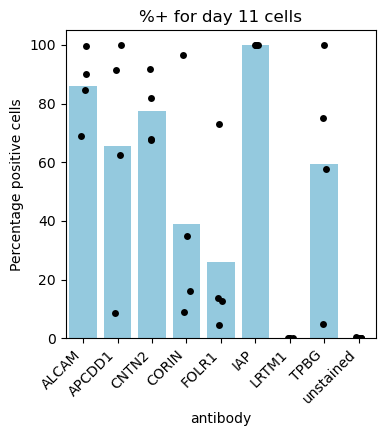

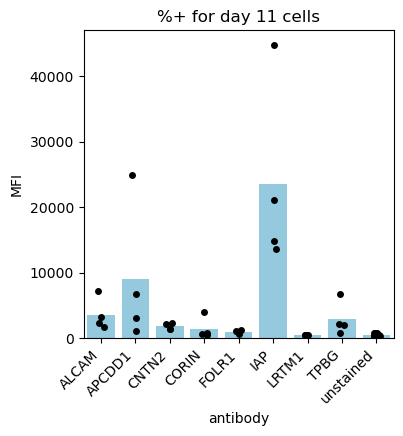

In [10]:
#%+
plt.figure(figsize=(4, 4))
sns.barplot(data=df, x='antibody', y='per_pos', color='skyblue', errorbar=None)
sns.stripplot(data=df, x='antibody', y='per_pos', color='black', size=5, jitter=True)
plt.title('%+ for day 11 cells')
plt.ylabel('Percentage positive cells')
plt.xticks(rotation=45, ha='right')
plt.show()

#mfi
plt.figure(figsize=(4, 4))
sns.barplot(data=df, x='antibody', y='3sd_mfi', color='skyblue', errorbar=None)
sns.stripplot(data=df, x='antibody', y='3sd_mfi', color='black', size=5, jitter=True)
plt.title('%+ for day 11 cells')
plt.ylabel('MFI')
plt.xticks(rotation=45, ha='right')
plt.show()

Read cleaned data

In [11]:
d11 = pd.read_csv('output/regional_spec_d11 clean.csv')

#the following day 11 cells were analyzed:
#RC17 diff. d11, 5x vials, 13/5, cVM - 2020-05-13
#RC17 diff. d11 cells, started 17/8, cVM - 2020-08-17
#RC17 diff. d11 cells, started 7/9 cVM - 2020-09-07
#RC17 diff. d11 cells, Alison 210331 - 2021-03-31

#define the batches based on the filename
def culture_start(row):
    if 'batch_start_13_2f_5_' in row:
        return '2020-05-13'
    elif 'batch_start_7_2f_9_' in row:
        return '2020-09-07'
    elif 'batch_start_17_2f_8_' in row:
        return '2020-08-17'
    elif 'Alison' in row:
        return '2021-03-31'
    else:
        return 'unknown'

d11['culture_start'] = d11['filename'].apply(culture_start)
d11.drop(['date_analyzed', 'kind'], axis=1, inplace=True)
d11 = d11.sort_values(by=['antibody', 'culture_start'])
d11.head()

,filename,live_cells_gate_events,g5_gate_events,3sd_mfi,per_pos,antibody,culture_start
2,batch_start_13_2f_5_ALCAM_1_3a_100_cVM_002.fcs,8190,6939,1690.4653,84.73,ALCAM,2020-05-13
3,batch_start_17_2f_8_ALCAM_1_3a_100_cVM_014.fcs,7981,5497,2264.4832,68.88,ALCAM,2020-08-17
1,batch_start_7_2f_9_ALCAM_1_3a_100_cVM_026.fcs,8268,7459,3180.1020,90.22,ALCAM,2020-09-07
0,Alison_ALCAM_1_3a_100_cVM_038.fcs,8661,8624,7193.2240,99.57,ALCAM,2021-03-31
4,batch_start_13_2f_5_APCDD1_1_3a_100_cVM_003.fcs,8176,716,3117.3599,8.76,APCDD1,2020-05-13


# Merge py data with reference

Import and plot reference data

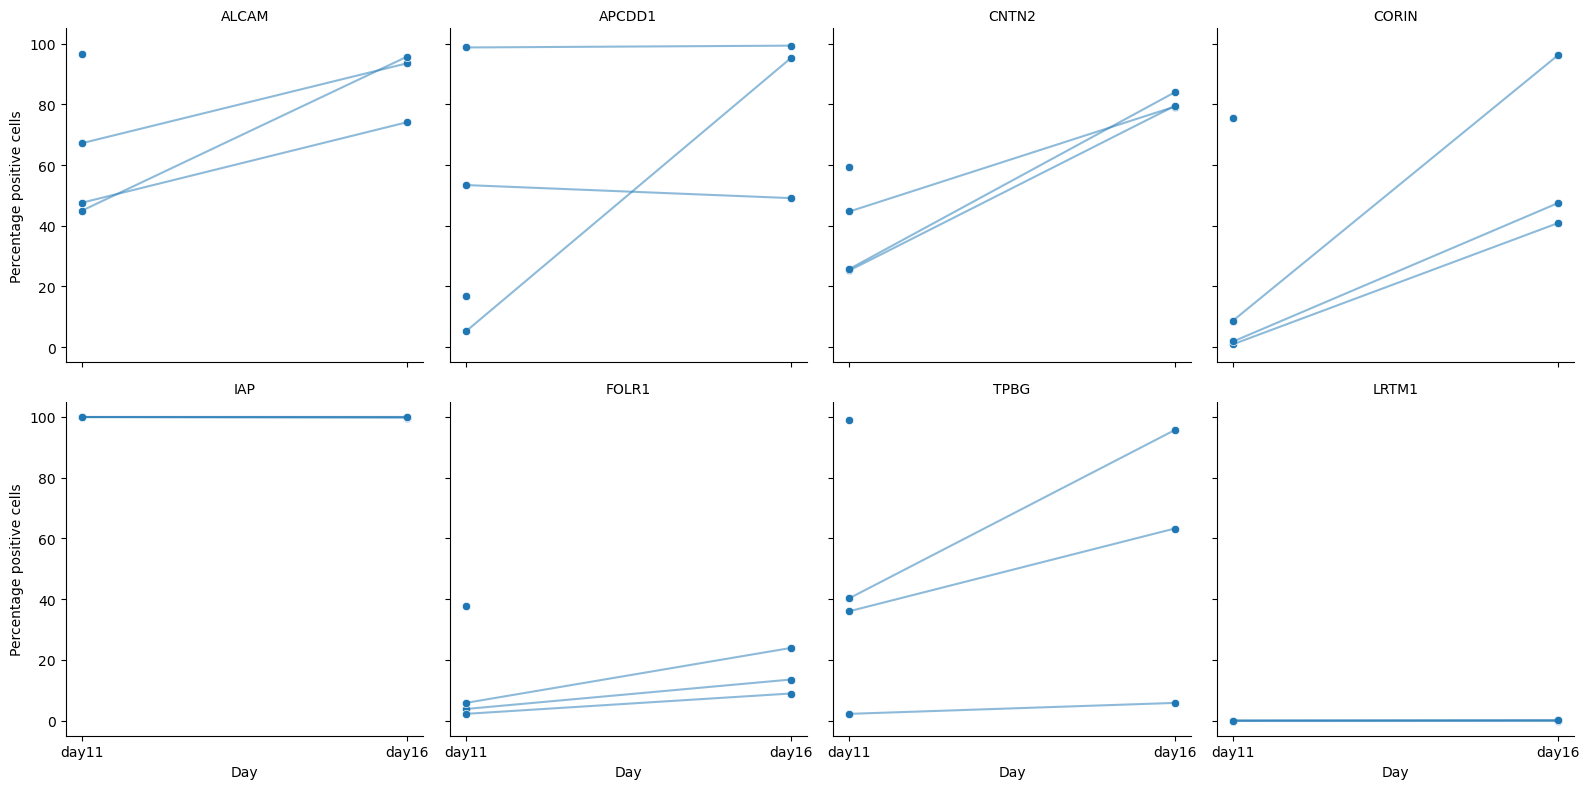

In [12]:
#column names (arrange is increasing percentage positive)
col_names = ['antibody', 'batch1', 'batch3', 'batch2', 'batch4', 'day']

ref = pd.read_csv('data/regional spec d11 d16.csv', decimal=',', sep=';', names=col_names, header=None, usecols=[0, 1, 2, 3, 4, 5])

#melt the batch1, batch2, batch3, batch4 columns. these contain the percentage positive values, create a new column with the batch number
ref = ref.melt(id_vars=['antibody', 'day'], value_vars=['batch1', 'batch2', 'batch3', 'batch4'], var_name='batch', value_name='per_pos')

#plot the data as dotplots with lines connecting matching values. each antibody should be on a subplot, the x-axis should be the day and the y-axis the percentage positive
g = sns.FacetGrid(ref, col='antibody', col_wrap=4, height=4, aspect=1)
g.map(sns.scatterplot, 'day', 'per_pos')
g.map_dataframe(sns.lineplot, 'day', 'per_pos', estimator=None, units='batch', alpha=0.5)

g.set_titles('{col_name}')
g.set_axis_labels('Day', 'Percentage positive cells')
plt.show()

## Merge

Read full data

In [13]:
#read the full data
full = pd.read_csv('data/regional spec cleaned processed merged py manual 250115.csv')

#the following culture_start dates are of interest
#RC17 diff. d11, 5x vials, 13/5, cVM - 2020-05-13
#RC17 diff. d11 cells, started 17/8, cVM - 2020-08-17
#RC17 diff. d11 cells, started 7/9 cVM - 2020-09-07
#RC17 diff. d11 cells, Alison 210331 - 2021-03-31

#select the relevant dates
rel_dates = ['2020-05-13', '2020-08-17', '2020-09-07', '2021-03-31']
full_rel_dates = full[full['culture_start'].isin(rel_dates)]
full_rel_dates = full_rel_dates[full_rel_dates['region'] == 'cVM']

full_rel_dates = full_rel_dates[['antibody', 'date_analyzed', 'fluo', 'culture_start', 'batch', 'per_pos_py', 'dissoc']]
full_rel_dates.sort_values(by=['antibody', 'culture_start', 'date_analyzed'], inplace=True)

full_rel_dates.head(5)

,antibody,date_analyzed,fluo,culture_start,batch,per_pos_py,dissoc
0,ALCAM,2020-06-17,pe,2020-05-13,2,94.57,tryp
46,ALCAM,2020-06-27,pe,2020-05-13,2,88.88,pap
296,ALCAM,2021-03-11,pe,2020-08-17,5,98.88,acc
717,ALCAM,2021-04-28,pe,2020-08-17,5,93.03,pap
738,ALCAM,2021-04-28,pe,2020-08-17,5,97.89,tryp


In [14]:
#select the following columns antibody, date_analyzed, culture_start, per_pos_py
full_rel_dates = full_rel_dates[['antibody', 'date_analyzed', 'culture_start', 'per_pos_py']]

#sort the data
full_rel_dates.sort_values(by=['date_analyzed', 'antibody'], inplace=True)

#rename per_pos_py to per_pos
full_rel_dates.rename(columns={'per_pos_py': 'per_pos'}, inplace=True)

#rearrange columns and sort
full_rel_dates = full_rel_dates[['culture_start', 'date_analyzed', 'antibody', 'per_pos']]
full_rel_dates.sort_values(['antibody', 'culture_start', 'date_analyzed', 'per_pos'], inplace=True)

full_rel_dates.head()

,culture_start,date_analyzed,antibody,per_pos
0,2020-05-13,2020-06-17,ALCAM,94.57
46,2020-05-13,2020-06-27,ALCAM,88.88
296,2020-08-17,2021-03-11,ALCAM,98.88
717,2020-08-17,2021-04-28,ALCAM,93.03
738,2020-08-17,2021-04-28,ALCAM,97.89


In [15]:
#merge the d11 and full_rel_dates (full py data)
merged = pd.merge(d11, full_rel_dates, how='left', on=['antibody', 'culture_start'], suffixes=('_d11', '_d16'))
merged.head(5)

,filename,live_cells_gate_events,g5_gate_events,3sd_mfi,per_pos_d11,antibody,culture_start,date_analyzed,per_pos_d16
0,batch_start_13_2f_5_ALCAM_1_3a_100_cVM_002.fcs,8190,6939,1690.4653,84.73,ALCAM,2020-05-13,2020-06-17,94.57
1,batch_start_13_2f_5_ALCAM_1_3a_100_cVM_002.fcs,8190,6939,1690.4653,84.73,ALCAM,2020-05-13,2020-06-27,88.88
2,batch_start_17_2f_8_ALCAM_1_3a_100_cVM_014.fcs,7981,5497,2264.4832,68.88,ALCAM,2020-08-17,2021-03-11,98.88
3,batch_start_17_2f_8_ALCAM_1_3a_100_cVM_014.fcs,7981,5497,2264.4832,68.88,ALCAM,2020-08-17,2021-04-28,93.03
4,batch_start_17_2f_8_ALCAM_1_3a_100_cVM_014.fcs,7981,5497,2264.4832,68.88,ALCAM,2020-08-17,2021-04-28,97.89


In [16]:
#melt the per_pos_d11 and per_pos_d16 columns
merged = merged.melt(id_vars=['antibody', 'culture_start'], 
                     value_vars=['per_pos_d11', 'per_pos_d16'], 
                     var_name='day', 
                     value_name='per_pos')

#remove the string 'per_pos_' from the day column
merged['day'] = merged['day'].str.replace('per_pos_', '')

merged.sort_values(by=['antibody', 'culture_start', 'day'], inplace=True)
merged.head(10)

,antibody,culture_start,day,per_pos
0,ALCAM,2020-05-13,d11,84.73
1,ALCAM,2020-05-13,d11,84.73
101,ALCAM,2020-05-13,d16,94.57
102,ALCAM,2020-05-13,d16,88.88
2,ALCAM,2020-08-17,d11,68.88
3,ALCAM,2020-08-17,d11,68.88
4,ALCAM,2020-08-17,d11,68.88
103,ALCAM,2020-08-17,d16,98.88
104,ALCAM,2020-08-17,d16,93.03
105,ALCAM,2020-08-17,d16,97.89


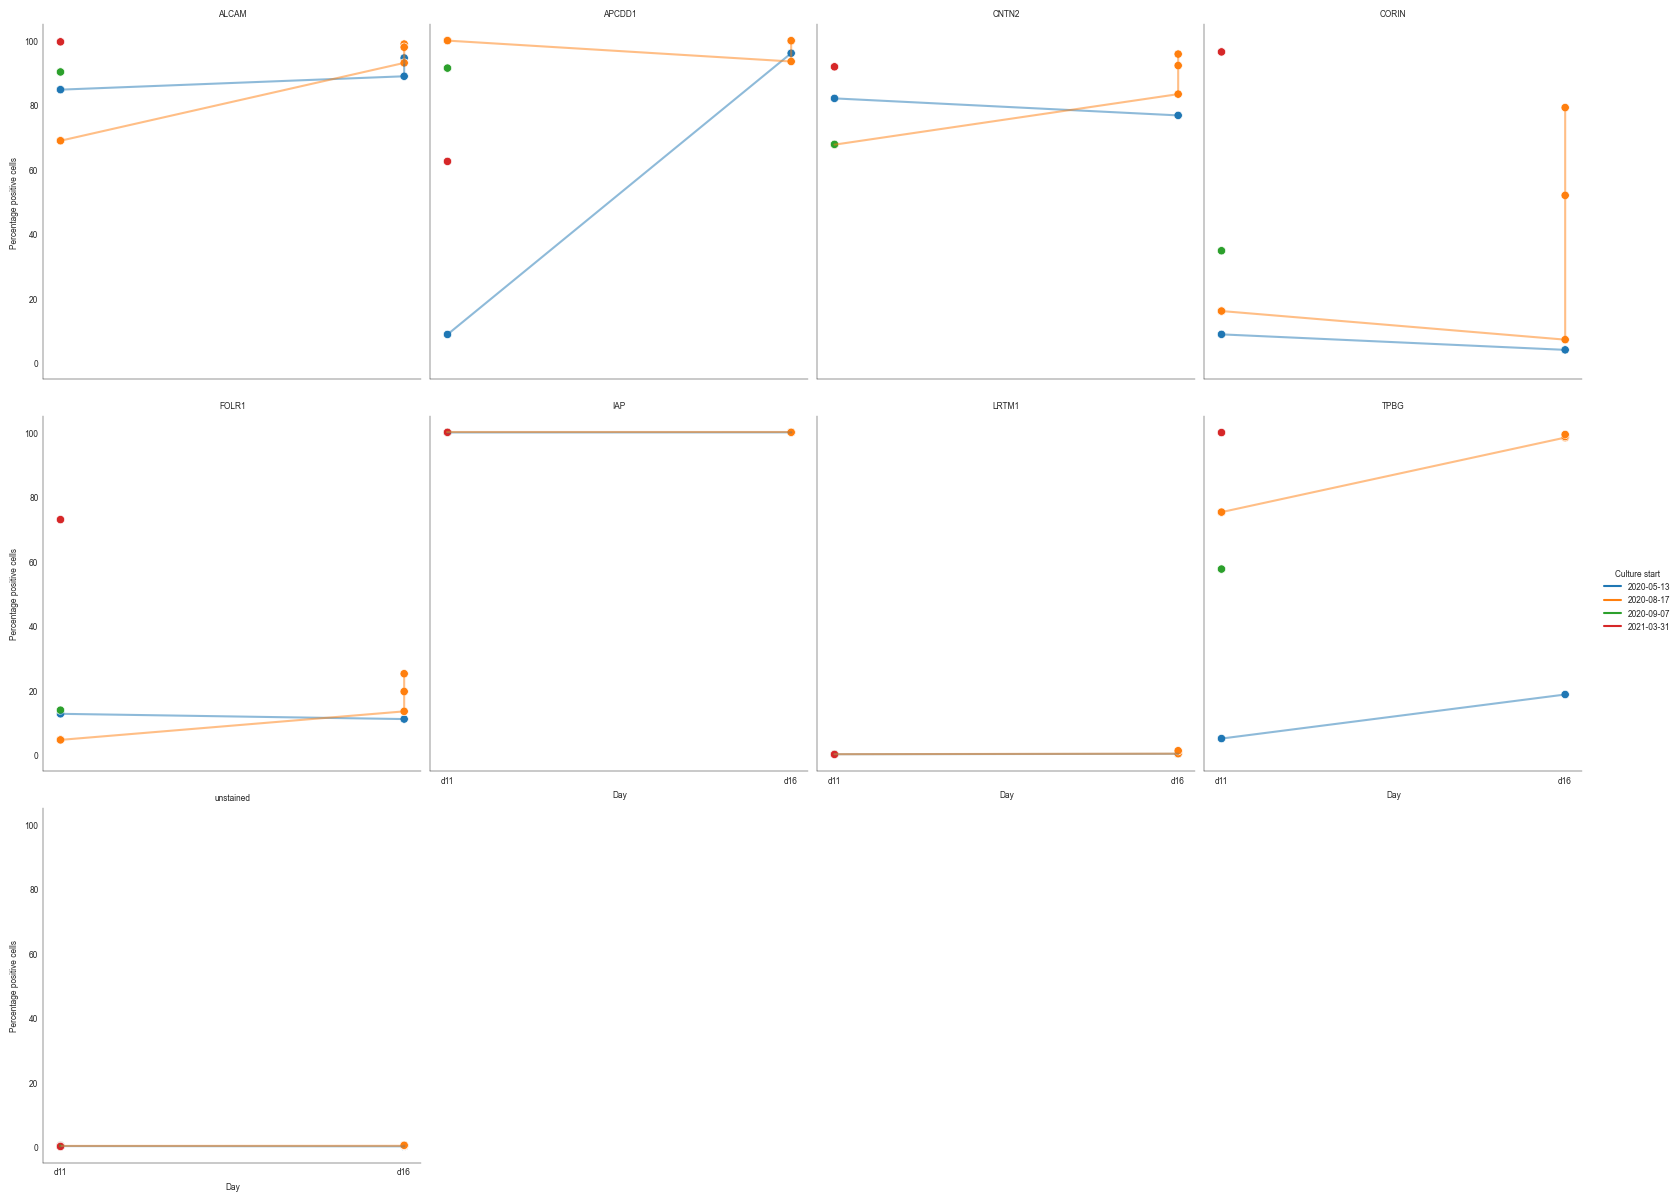

In [17]:
#plot %+ with lines connecting matching batches
custom_theme_6pt()
g = sns.FacetGrid(merged, col='antibody', col_wrap=4, height=4, aspect=1)
g.map_dataframe(sns.scatterplot, 'day', 'per_pos', hue='culture_start')
g.map_dataframe(sns.lineplot, 'day', 'per_pos', estimator=None, units='culture_start', alpha=0.5, hue='culture_start')
g.set_titles('{col_name}')
g.add_legend(title='Culture start') #add legend
g.set_axis_labels('Day', 'Percentage positive cells')
plt.show()

## Investigate the data

In [18]:
#there's data missing. Investigate and fix 
#culture_start==2020-09-07 d11 should connect to one of culture_start==2020-08-17 d16. 
#additionally, there are several culture_start==2020-08-17 for d16, which doesn't make sense

#read the full data
full = pd.read_csv('data/regional spec cleaned processed merged py manual 250115.csv')
full.head()

,antibody,date_analyzed,region,dissoc,fluo,culture_start,batch,mfi,per_pos_py,3sd_per_pos,...,10sd_per_pos,15sd_per_pos,20sd_per_pos,30sd_per_pos,10sd_mfi,3sd_mfi,3sd_mfi_norm,mfi_norm,mfi_norm_boxcox,mfi_norm_log10
0,ALCAM,2020-06-17,cVM,tryp,pe,2020-05-13,2,2080.70,94.57,96.93,...,88.59,82.19,76.48,65.21,2724.13,2142.52,2142.520000,2080.700000,18.049082,3.318209
1,ALCAM,2020-06-17,dFB,tryp,pe,2020-05-13,2,540.88,82.96,91.66,...,56.84,34.65,19.44,5.38,1281.00,578.07,1.659383,7.809121,2.726032,0.892602
2,APCDD1,2020-06-17,dFB,tryp,pe,2020-05-13,2,254.42,31.55,52.71,...,10.24,4.99,3.10,1.54,1992.94,377.05,0.734600,3.143648,1.644259,0.497434
3,CNTN2,2020-06-17,dFB,tryp,pe,2020-05-13,2,1407.34,80.32,84.52,...,68.18,56.72,47.17,33.60,2971.17,1661.11,6.641855,21.920847,4.354404,1.340857
4,CORIN,2020-06-17,dFB,tryp,pe,2020-05-13,2,74.13,1.65,7.21,...,0.06,0.00,0.00,0.00,NaN,223.25,0.027051,0.207329,0.192005,-0.683340


In [19]:
#the following culture_start dates are of interest
#RC17 diff. d11, 5x vials, 13/5, cVM - 2020-05-13
#RC17 diff. d11 cells, started 17/8, cVM - 2020-08-17
#RC17 diff. d11 cells, started 7/9 cVM - 2020-09-07
#RC17 diff. d11 cells, Alison 210331 - 2021-03-31

#select the relevant dates
rel_dates = ['2020-05-13', '2020-08-17', '2020-09-07', '2021-03-31']
full_rel_dates = full[full['culture_start'].isin(rel_dates)]
full_rel_dates = full_rel_dates[full_rel_dates['region'] == 'cVM']

#select relevant columns and sort
full_rel_dates = full_rel_dates[['antibody', 'date_analyzed', 'culture_start', '3sd_mfi', 'per_pos_py', 'dissoc']]
full_rel_dates.sort_values(by=['antibody', 'culture_start', 'date_analyzed', '3sd_mfi'], inplace=True)

full_rel_dates_lrtm1 = full_rel_dates[full_rel_dates['antibody'] == 'LRTM1']
full_rel_dates_lrtm1.head()

,antibody,date_analyzed,culture_start,3sd_mfi,per_pos_py,dissoc
51,LRTM1,2020-06-27,2020-05-13,332.45,0.24,pap
294,LRTM1,2021-03-11,2020-08-17,413.30,0.68,acc
713,LRTM1,2021-04-28,2020-08-17,400.57,0.29,pap
734,LRTM1,2021-04-28,2020-08-17,425.89,1.20,tryp


In [20]:
#check the culture_start==2020-08-17:
#date_analyzed: 2021-03-11 & 2021-04-28

#2020-09-07
#for corin at 2020-08-17:
#merge the two highest points and rename to 2020-09-07

#calculate the mean percentage positive for each antibody and date_analyzed in the case that there are multiple values (since dissoc can be either tryp or acc)
full_rel_dates = full_rel_dates.groupby(['antibody', 'culture_start', 'date_analyzed']).agg({'3sd_mfi': 'mean', 'per_pos_py' : 'mean'}).reset_index()
cols_to_round = ['3sd_mfi', 'per_pos_py']
full_rel_dates[cols_to_round] = full_rel_dates[cols_to_round].round(2)

#when culture_start==2020-08-17 & date_analyzed==2021-04-28, change culture_start to 2020-09-07
full_rel_dates.loc[(full_rel_dates['culture_start'] == '2020-08-17') & (full_rel_dates['date_analyzed'] == '2021-04-28'), 'culture_start'] = '2020-09-07' 

full_rel_dates.head(45)

,antibody,culture_start,date_analyzed,3sd_mfi,per_pos_py
0,ALCAM,2020-05-13,2020-06-17,2142.52,94.57
1,ALCAM,2020-05-13,2020-06-27,1797.54,88.88
2,ALCAM,2020-08-17,2021-03-11,4203.95,98.88
3,ALCAM,2020-09-07,2021-04-28,3968.55,95.46
4,APCDD1,2020-05-13,2020-06-27,1473.97,96.04
5,APCDD1,2020-08-17,2021-03-11,12042.88,99.89
6,APCDD1,2020-09-07,2021-04-28,6777.50,96.70
7,CNTN2,2020-05-13,2020-06-27,998.24,76.74
8,CNTN2,2020-08-17,2021-03-11,2642.47,95.77
9,CNTN2,2020-09-07,2021-04-28,1995.54,87.78


In [21]:
#rename per_pos_py to per_pos

#rearrange columns and sort
full_rel_dates = full_rel_dates[['culture_start', 'antibody', '3sd_mfi', 'per_pos_py']]
full_rel_dates.sort_values(['antibody', 'culture_start', '3sd_mfi', 'per_pos_py'], inplace=True)

#rename per_pos_py to per_pos
full_rel_dates.rename(columns={'per_pos_py': 'per_pos'}, inplace=True)
full_rel_dates.head(10)

,culture_start,antibody,3sd_mfi,per_pos
1,2020-05-13,ALCAM,1797.54,88.88
0,2020-05-13,ALCAM,2142.52,94.57
2,2020-08-17,ALCAM,4203.95,98.88
3,2020-09-07,ALCAM,3968.55,95.46
4,2020-05-13,APCDD1,1473.97,96.04
5,2020-08-17,APCDD1,12042.88,99.89
6,2020-09-07,APCDD1,6777.50,96.70
7,2020-05-13,CNTN2,998.24,76.74
8,2020-08-17,CNTN2,2642.47,95.77
9,2020-09-07,CNTN2,1995.54,87.78


In [22]:
#merge the d11 and full_rel_dates
merged = pd.merge(d11, full_rel_dates, how='left', on=['antibody', 'culture_start'], suffixes=('_d11', '_d16'))

#remove the columns that are unnecessary
merged.drop(['live_cells_gate_events', 'g5_gate_events'], axis=1, inplace=True)
merged.head(5)

,filename,3sd_mfi_d11,per_pos_d11,antibody,culture_start,3sd_mfi_d16,per_pos_d16
0,batch_start_13_2f_5_ALCAM_1_3a_100_cVM_002.fcs,1690.4653,84.73,ALCAM,2020-05-13,1797.54,88.88
1,batch_start_13_2f_5_ALCAM_1_3a_100_cVM_002.fcs,1690.4653,84.73,ALCAM,2020-05-13,2142.52,94.57
2,batch_start_17_2f_8_ALCAM_1_3a_100_cVM_014.fcs,2264.4832,68.88,ALCAM,2020-08-17,4203.95,98.88
3,batch_start_7_2f_9_ALCAM_1_3a_100_cVM_026.fcs,3180.1020,90.22,ALCAM,2020-09-07,3968.55,95.46
4,Alison_ALCAM_1_3a_100_cVM_038.fcs,7193.2240,99.57,ALCAM,2021-03-31,NaN,NaN


In [23]:
merged_copy = merged.copy()

#melt the 3sd_mfi_d11 and 3sd_mfi_d16 columns
merged_copy = merged_copy.melt(id_vars=['antibody', 'culture_start', 'per_pos_d11', 'per_pos_d16'], 
                     value_vars=['3sd_mfi_d11', '3sd_mfi_d16'], 
                     var_name='day_mfi', 
                     value_name='3sd_mfi')

#remove the string '3sd_mfi_' from the columns
merged_copy['day_mfi'] = merged_copy['day_mfi'].str.replace('3sd_mfi_', '')


#melt the per_pos_d11 and per_pos_d16 columns
merged_copy = merged_copy.melt(id_vars=['antibody', 'culture_start', 'day_mfi', '3sd_mfi'], 
                     value_vars=['per_pos_d11', 'per_pos_d16'], 
                     var_name='day_per_pos', 
                     value_name='per_pos')

#remove the string 'per_pos_' from the columns
merged_copy['day_per_pos'] = merged_copy['day_per_pos'].str.replace('per_pos_', '')

print(merged_copy.shape)


#keep rows where day_mfi==d11 and day_per_pos==d11 or day_per_pos==d16 and day_mfi==d16
merged_copy = merged_copy[((merged_copy['day_mfi'] == 'd11') & (merged_copy['day_per_pos'] == 'd11')) | ((merged_copy['day_mfi'] == 'd16') & (merged_copy['day_per_pos'] == 'd16'))]


print(merged_copy.shape)


#drop the day_per_pos column
merged_copy.drop(['day_per_pos'], axis=1, inplace=True)

#rename the day_mfi column to day
merged_copy.rename(columns={'day_mfi': 'day'}, inplace=True)


merged_copy.sort_values(by=['antibody', 'culture_start', 'day'], inplace=True)
merged_copy.head()

(196, 6)
(98, 6)


,antibody,culture_start,day,3sd_mfi,per_pos
0,ALCAM,2020-05-13,d11,1690.4653,84.73
1,ALCAM,2020-05-13,d11,1690.4653,84.73
147,ALCAM,2020-05-13,d16,1797.5400,88.88
148,ALCAM,2020-05-13,d16,2142.5200,94.57
2,ALCAM,2020-08-17,d11,2264.4832,68.88


In [24]:
merged_copy = merged_copy[merged_copy['culture_start'] != '2021-03-31']

#export the cleaned, merged data
merged_copy.to_csv('output/regional_spec_py_d11_cleaned_merged.csv', index=False)

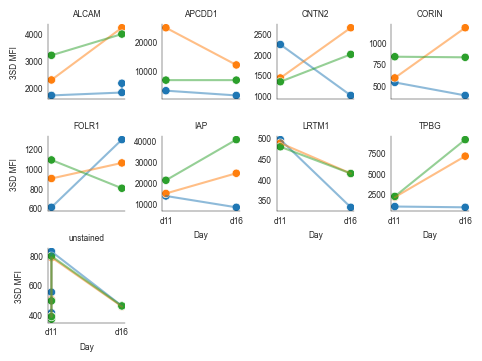

In [25]:
#plot the data as dotplots with lines connecting matching values. each antibody should be on a subplot, the x-axis should be the day and the y-axis the percentage positive
#remove culture_start==2021-03-31

custom_theme_6pt()
g = sns.FacetGrid(merged_copy, col='antibody', col_wrap=4, height=1.2, aspect=1, sharey=False)
g.map_dataframe(sns.scatterplot, 'day', '3sd_mfi', hue='culture_start')
g.map_dataframe(sns.lineplot, 'day', '3sd_mfi', estimator=None, units='culture_start', alpha=0.5, hue='culture_start')

g.set_titles('{col_name}')
g.set_axis_labels('Day', '3SD MFI')
g.fig.subplots_adjust(hspace=0.4, wspace=0.4)
plt.tight_layout()
plt.savefig('figs/3sd_mfi_d11_d16.pdf', dpi=300)

plt.show()

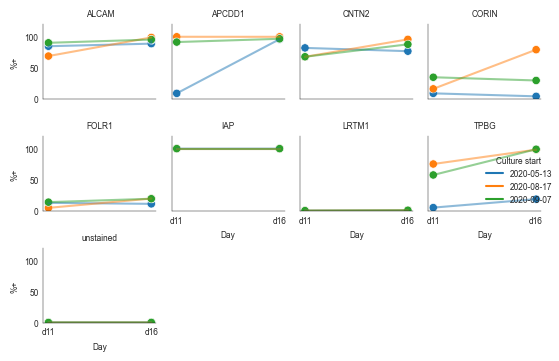

In [26]:
#plot %+ with lines connecting matching batches
#remove culture_start==2021-03-31

custom_theme_6pt()
g = sns.FacetGrid(merged_copy, col='antibody', col_wrap=4, height=1.2, aspect=1, sharey=True)
g.map_dataframe(sns.scatterplot, 'day', 'per_pos', hue='culture_start')
g.map_dataframe(sns.lineplot, 'day', 'per_pos', estimator=None, units='culture_start', alpha=0.5, hue='culture_start')
g.set_titles('{col_name}')
g.add_legend(title='Culture start')
g.set_axis_labels('Day', '%+')
g.fig.subplots_adjust(hspace=0.4, wspace=0.4)
g.set(ylim=(0, 120))
plt.tight_layout()
plt.savefig('figs/per_pos_mfi_d11_d16.pdf', dpi=300)
plt.show()